# Прогнозирования CTR для рекламных объявлений

<h3>Цель проекта: </h3>
<p>Создание модели предсказания отклика на рекламное предложение, для минимизации затрат на рекламу</p>

<h3>Структура проекта</h3>
<ul>
    <p>1. Подготовка среды и загрузка данных</p>
    <p>2. Исследовательский анализ данных (EDA)</p>
    <p>4. Предобработка данных(выборки, пайплайны по EDA)</p>
    <p>5. Обучение базовой модели</p>
    <p>6. Подбор гиперпараметров: Grid Search с кросс-валидацией</p>
    <p>7. Финальная модель </p>
    <p>8. Калибровка модели</p>
    <p>9. Финальный отчет</p>
</ul>

## Подготовка среды и загрузка данных
- 1.1 Подготовьте библиотеки и постоянных параметров(random_state, отображение)
- 1.2 Загрузка данных

### Подготовьте библиотеки и постоянных параметров(random_state, отображение)
- Импортируем все необходимые библиотеки.
- Настроим параметры отображения графиков и датафреймов.
- Установим константу `RANDOM_SEED`.

In [1]:
!pip install phik
!pip install category_encoders

import numpy as np
import pandas as pd
import phik

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, cross_validate)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (VarianceThreshold, SelectKBest, mutual_info_classif, RFE, SequentialFeatureSelector)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier

from sklearn.calibration import (CalibratedClassifierCV, calibration_curve)

from sklearn.metrics import (average_precision_score, log_loss, brier_score_loss, precision_score, recall_score, f1_score, classification_report)
from sklearn.svm import SVC

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


- подключены библиотеки для анализа данных, визуализации, ML
- настроены параметры отображения графиков
- зафиксирован параметр RANDOM_STATE

### Загрузка данных
- Прочитаем CSV-файл с данными. 
- Выведем размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверим успешность загрузки данных.

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')
print(df.info())
print('Количество строк:', df.shape[0])
print('Количество столбцов:', df.shape[1])
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


## 2. Исследовательский анализ данных (EDA)

- 2.1 Опишем базовую информацию о датасете
- 2.2 Анализ целевой переменной
- 2.3 Анализ признаков
- 2.4 Анализ пропущенных значений и дубликатов
- 2.5 Анализ категориальных признаков
- 2.6 Анализ выбросов и распределений
- 2.7 Корреляции

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

### Опишем базовую информацию о датасете
- сколько объектов и признаков содержится в данных.
- какие типы данных представлены (числовые, категориальные).
- общее описание: что известно о пользователях и рекламе.

In [3]:
print(df.info())
print('Количество строк:', df.shape[0])
print('Количество столбцов:', df.shape[1])
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


<h4>Первичный анализ по выгруженным данным</h4>
<ul>
    <li>Общий объём данных 34 столбца и 50000 строк<li>
    <li>Явных пропусков(значений NULL) нет, следует проверить уникальные значения признаков на наличие значений подобных unknown или -1</li>
    <li>Есть ненужные id после проверки на дубликаты их нужно исключить</li>
    <li>Нам даны уже готовые признаки и свойства, не имеющие явной бизнес интерпритации, следовательно задача просто найти самые важные из них</li>
    <li>Признак hour храниться в формате YYMMDDHH из него можно дополнительно извлечь день месяца, день недели и выходные дни</li> 
    <li>необходимо отдельно проанализировать баланс целевой переменной click. Это повлияет на выбор метрик и стратегию обучения моделей.</li>
</ul>

###  Анализ целевой переменной
- Проанализируем, как распределена целевая переменная.
- Есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитаем долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

Количество объектов:
click
0    41397
1     8603
Name: count, dtype: int64
Доли классов:
click
0    0.82794
1    0.17206
Name: proportion, dtype: float64


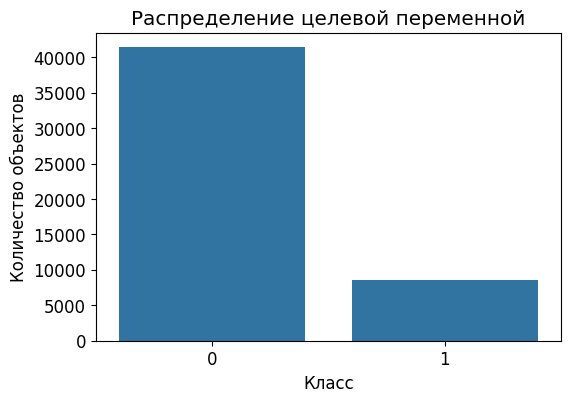

In [4]:
click_counts = df['click'].value_counts()
click_share = df['click'].value_counts(normalize=True)

print('Количество объектов:')
print(click_counts)

print('Доли классов:')
print(click_share)

plt.figure(figsize=(6, 4))

sns.countplot(x='click', data=df)

plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')

plt.show()

Вывод:

- доля кликов меньше доли некликов, наблюдается дисбаланс.
- accuracy не подходит как основная метрика;
- необходимо использовать PR-AUC;
- при анализе модели необходимо учесть предсказания положительного класса.

### Анализ признаков
- Есть ли среди признаков явно бесполезные
- Какие признаки категориальные, а какие — числовые.
- Удалим ненужные признаки.

In [5]:
df.dtypes

id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id                 str
site_domain             str
site_category           str
app_id                  str
app_domain              str
app_category            str
device_id               str
device_ip               str
device_model            str
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
ml_feature_1        float64
ml_feature_2            str
ml_feature_3        float64
ml_feature_4          int64
ml_feature_5        float64
ml_feature_6        float64
ml_feature_7            str
ml_feature_8        float64
ml_feature_9        float64
ml_feature_10       float64
dtype: object

#### Признаки:
Категориальные признаки:  
site_id, site_domain, site_category, app_id, app_domain, app_category, device_id, device_ip, device_model, ml_feature_2, ml_feature_7.

Числовые признаки:  
hour, C1, banner_pos, device_type, device_conn_type, C14, C15, C16, C17, C18, C19, C20, C21, ml_feature_1, ml_feature_3, ml_feature_4, ml_feature_5, ml_feature_6, ml_feature_8, ml_feature_9, ml_feature_10.

- id идентификатор будет удаоены перед  обучением 
- click целевая переменная.
- device_ip не несет полезной информации можно удалить
- device_id, site_id, app_id из них можно извлечь поведение пользователя и популярность сайта оставим для дальнейшего анализа

##### Рассмотрим уникальные значения в данных

In [6]:
unique_counts = df.nunique().sort_values()
print(unique_counts)

click                   2
ml_feature_4            2
ml_feature_7            3
device_type             4
device_conn_type        4
C18                     4
ml_feature_2            5
C1                      7
banner_pos              7
C15                     8
C16                     9
site_category          18
app_category           22
C21                    59
C19                    64
app_domain             67
C20                   149
hour                  240
C17                   387
app_id                976
site_domain          1013
site_id              1160
C14                  1497
device_model         2521
device_id            8580
device_ip           41455
id                  50000
ml_feature_1        50000
ml_feature_3        50000
ml_feature_5        50000
ml_feature_6        50000
ml_feature_8        50000
ml_feature_9        50000
ml_feature_10       50000
dtype: int64


Признак hour не несёт смысла разделкм его на 4 новых столбца 

In [7]:
df['year'] = 2000 + df['hour'] // 1000000
df['month'] = (df['hour'] // 10000) % 100
df['day'] = (df['hour'] // 100) % 100
df['hour_'] = df['hour'] % 100
print(df[['hour', 'year', 'month', 'day', 'hour_']].head())

       hour  year  month  day  hour_
0  14102100  2014     10   21      0
1  14102100  2014     10   21      0
2  14102100  2014     10   21      0
3  14102100  2014     10   21      0
4  14102100  2014     10   21      0


Вывод по анализу уникальных значений признаков

- В датасете присутствуют признаки с 50000 уникальными значениями, тоесть они уникальны на каждой строке:  
  id, ml_feature_1, ml_feature_3, ml_feature_5, ml_feature_6, ml_feature_8, ml_feature_9, ml_feature_10  
  Эти признаки работают как уникальные идентификаторы и могут легко привести к переобучению, так как практически не содержат паттернов для запоминания.

- Признак device_ip также имеет очень много  уникальных значений(41 455), что делает его близким к идентификатору пользователя/устройства. Это может приводить к ухудшению обобщающей способности модели.

- Признаки device_id, site_id, app_id, device_model могут содержать полезную информацию о поведении пользователей и рекламных площадках. Требуется дополнительный анализ.

- Признаки C1, banner_pos, device_type, device_conn_type, C15–C21, ml_feature_2, ml_feature_7 являются категориальными признаками, подходящими для кодирования.

Перед обучением модели необходимо:
- удалить явные идентификаторы (id)
- обработать признаки с высокой кардинальностью 
- проверить влияние шумовых признаков на качество модели

### Обработка пропусков
- Проверим долю пропусков в каждом признаке.
- Выберем стратегию для заполнения пропусков удаление, среднее, медиана, мода. 

In [8]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

Series([], dtype: int64)


NULL значение не обнаружено, рассмотрим столбцы на наличие значений подобных unknown или -1 для этого рассмотрим уникальные значения в каждом столбце 

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    print("Столбец:", col)
    min_val = df[col].min()
    max_val = df[col].max()
    print("min:", min_val, "count min:", (df[col] == min_val).sum())
    print("max:", max_val, "count max:", (df[col] == max_val).sum())
    print()

Столбец: id
min: 31910769195310.0 count min: 1
max: 1.84465167508906e+19 count max: 1

Столбец: click
min: 0 count min: 41397
max: 1 count max: 8603

Столбец: hour
min: 14102100 count min: 159
max: 14103023 count max: 106

Столбец: C1
min: 1001 count min: 16
max: 1012 count max: 135

Столбец: banner_pos
min: 0 count min: 35883
max: 7 count max: 61

Столбец: device_type
min: 0 count min: 2790
max: 5 count max: 159

Столбец: device_conn_type
min: 0 count min: 43021
max: 5 count max: 42

Столбец: C14
min: 375 count min: 112
max: 24043 count max: 1

Столбец: C15
min: 120 count min: 1
max: 1024 count max: 5

Столбец: C16
min: 20 count min: 1
max: 1024 count max: 3

Столбец: C17
min: 112 count min: 312
max: 2757 count max: 3

Столбец: C18
min: 0 count min: 21074
max: 3 count max: 16855

Столбец: C19
min: 33 count min: 574
max: 1839 count max: 11

Столбец: C20
min: -1 count min: 23443
max: 100248 count max: 14

Столбец: C21
min: 13 count min: 495
max: 255 count max: 8

Столбец: ml_feature_1
m

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f'\nСтолбец: {col}')
    print(df[col].value_counts().head(10))


Столбец: site_id
site_id
85f751fd    18011
1fbe01fe     7968
e151e245     3234
d9750ee7     1262
5b08c53b     1120
5b4d2eda      982
856e6d3f      943
a7853007      577
b7e9786d      458
6256f5b4      440
Name: count, dtype: int64

Столбец: site_domain
site_domain
c4e18dd6    18645
f3845767     7968
7e091613     4088
7687a86e     1544
98572c79     1303
16a36ef3     1095
58a89a43      943
9d54950b      481
b12b9f85      465
28f93029      440
Name: count, dtype: int64

Столбец: site_category
site_category
50e219e0    20457
f028772b    15777
28905ebd     9061
3e814130     3729
f66779e6      310
75fa27f6      197
335d28a8      166
76b2941d      126
c0dd3be3       59
72722551       31
Name: count, dtype: int64

Столбец: app_id
app_id
ecad2386    31989
92f5800b     1954
e2fcccd2     1368
febd1138      904
9c13b419      876
7358e05e      755
a5184c22      627
d36838b1      573
54c5d545      499
685d1c4c      489
Name: count, dtype: int64

Столбец: app_domain
app_domain
7801e8d9    33763
2347

C:\Users\user\AppData\Local\Temp\ipykernel_19376\1406401874.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


В признаке C20 встречается 23443 значений -1 выглядит подозрительно при распределение нужно это учесть если выявиться что это паттерн на NULL необходима замена 

### Проверка на дубликаты

Полный дубликаты строк

In [11]:
print("Полные дубликаты:", df.duplicated().sum())

Полные дубликаты: 0


Дубликаты по id

In [12]:
print("Дубликаты id:", df['id'].duplicated().sum())

Дубликаты id: 0


ДУбликаты без учета id

In [13]:
cols_without_id = [col for col in df.columns if col != 'id']
print("Дубликаты без id:", df.duplicated(subset=cols_without_id).sum())

Дубликаты без id: 0


Дубликатов не обнаружено

### Анализ категориальных  признаков
- Сколько уникальных значений в каждом категориальном признаке.
- Какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.


In [14]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print("Столбец:", col)
    print("Уникальных значений:", df[col].nunique())
    print()

Столбец: site_id
Уникальных значений: 1160

Столбец: site_domain
Уникальных значений: 1013

Столбец: site_category
Уникальных значений: 18

Столбец: app_id
Уникальных значений: 976

Столбец: app_domain
Уникальных значений: 67

Столбец: app_category
Уникальных значений: 22

Столбец: device_id
Уникальных значений: 8580

Столбец: device_ip
Уникальных значений: 41455

Столбец: device_model
Уникальных значений: 2521

Столбец: ml_feature_2
Уникальных значений: 5

Столбец: ml_feature_7
Уникальных значений: 3



C:\Users\user\AppData\Local\Temp\ipykernel_19376\4117844960.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


One-Hot Encoding (низкая кардинальность)
- site_category (18)
- app_category (22)
- app_domain (67)
- ml_feature_2 (5)
- ml_feature_7 (3)


Target (средняя кардинальность)

- site_id (1160)
- app_id (976)

Специальные методы (высокая кардинальность)

- device_id (8580)
- device_model (2521)
- device_ip (41455)

### Анализ выбросов и распределления 
- Есть ли явные выбросы в числовых признаках.
- Как распределены выбросы — нормально, асимметрично, каким-то другим образом.

count    50000.000000
mean      1004.970060
std          1.110202
min       1001.000000
25%       1005.000000
50%       1005.000000
75%       1005.000000
max       1012.000000
Name: C1, dtype: float64
Выбросы:
Количество: 4165
Процент: 8.33
Границы: 1005.0 1005.0
Первые 5 выбросов выше верхней границы: [1007 1007 1007 1007 1007]
5 максимальных значений: [1012 1012 1012 1012 1012]


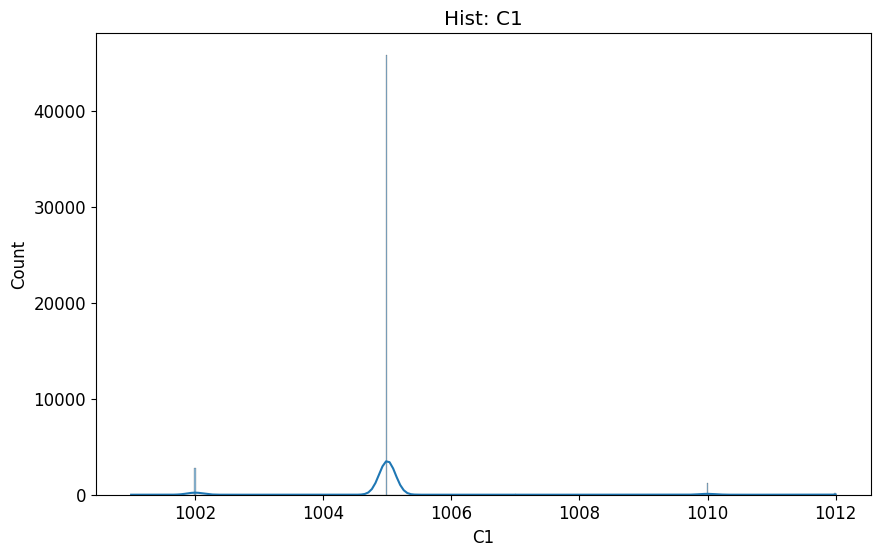

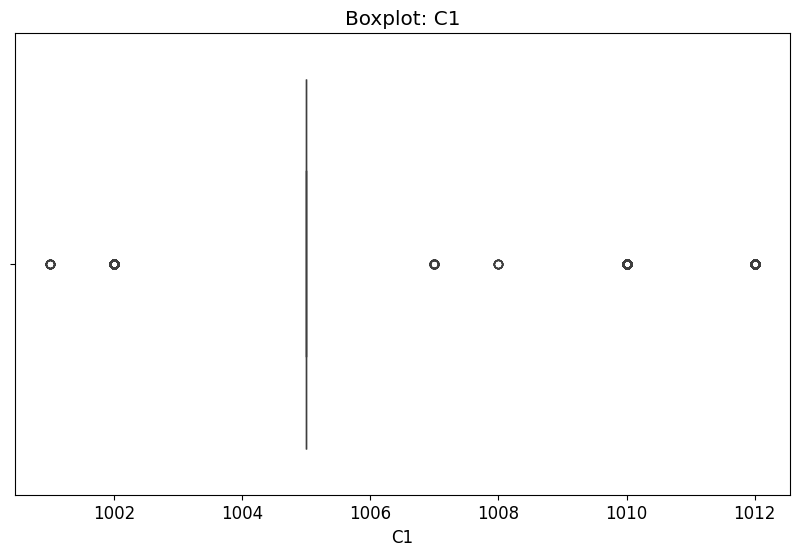

count    50000.000000
mean         0.291380
std          0.514201
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          7.000000
Name: banner_pos, dtype: float64
Выбросы:
Количество: 85
Процент: 0.17
Границы: -1.5 2.5
Первые 5 выбросов выше верхней границы: [3 3 3 3 3]
5 максимальных значений: [7 7 7 7 7]


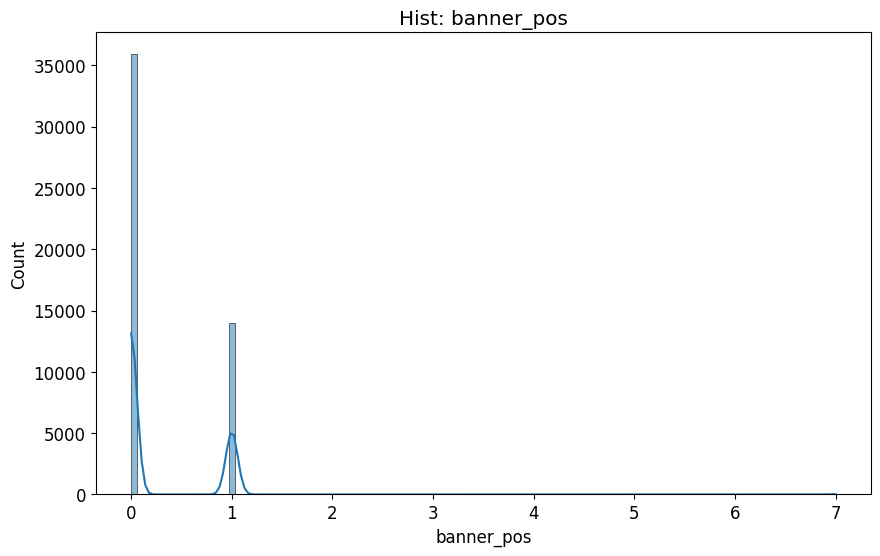

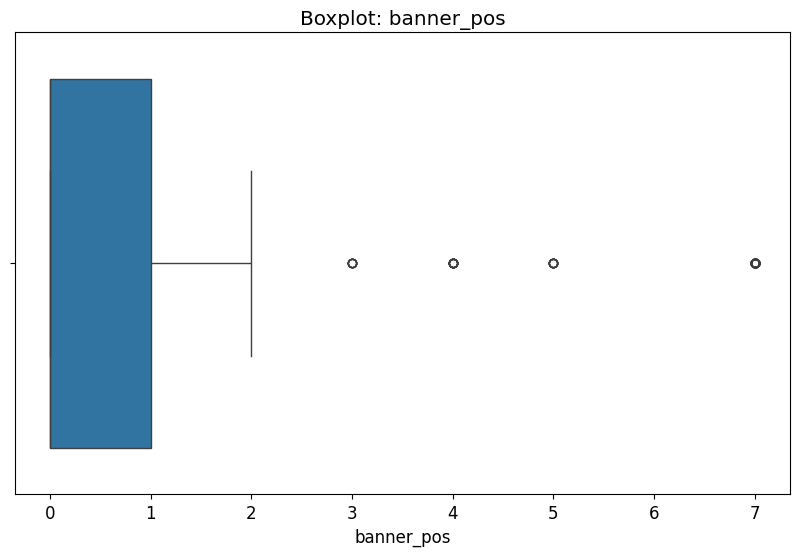

count    50000.000000
mean         1.018120
std          0.538477
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: device_type, dtype: float64
Выбросы:
Количество: 3969
Процент: 7.94
Границы: 1.0 1.0
Первые 5 выбросов выше верхней границы: [4 4 4 4 4]
5 максимальных значений: [5 5 5 5 5]


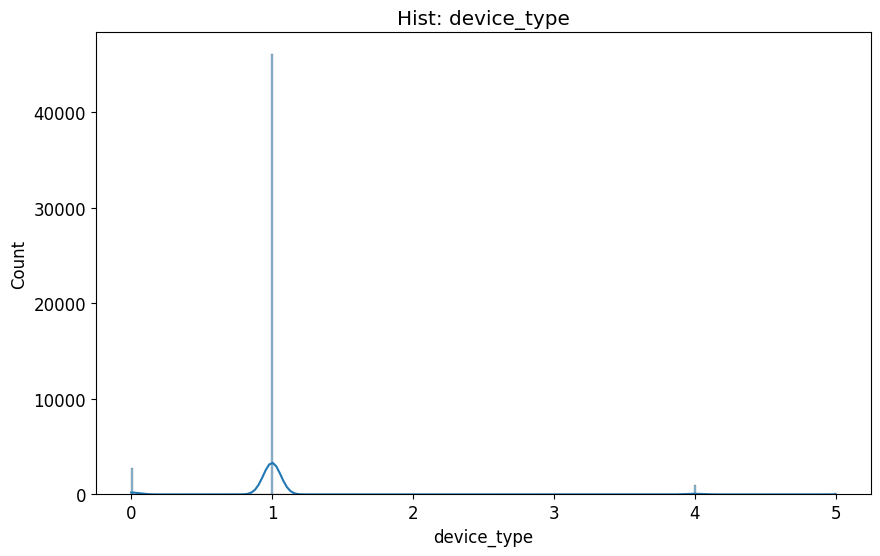

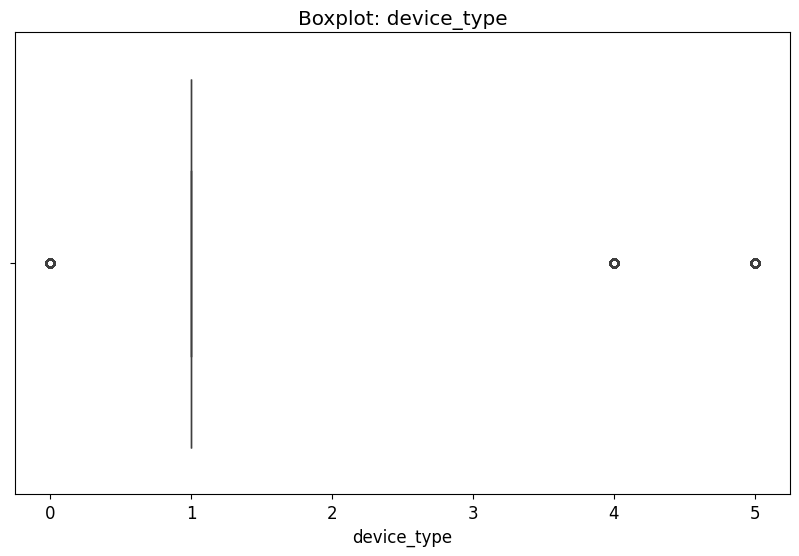

count    50000.000000
mean         0.337160
std          0.860057
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: device_conn_type, dtype: float64
Выбросы:
Количество: 6979
Процент: 13.96
Границы: 0.0 0.0
Первые 5 выбросов выше верхней границы: [2 2 2 2 2]
5 максимальных значений: [5 5 5 5 5]


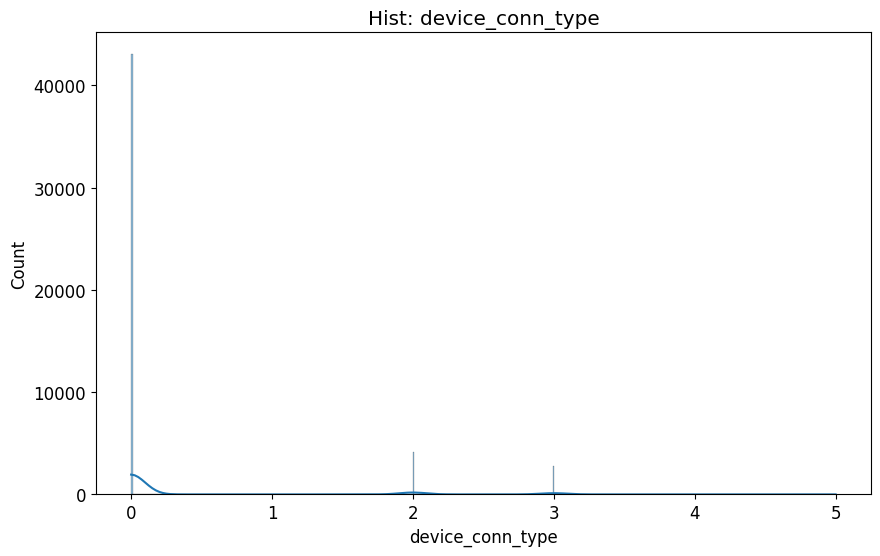

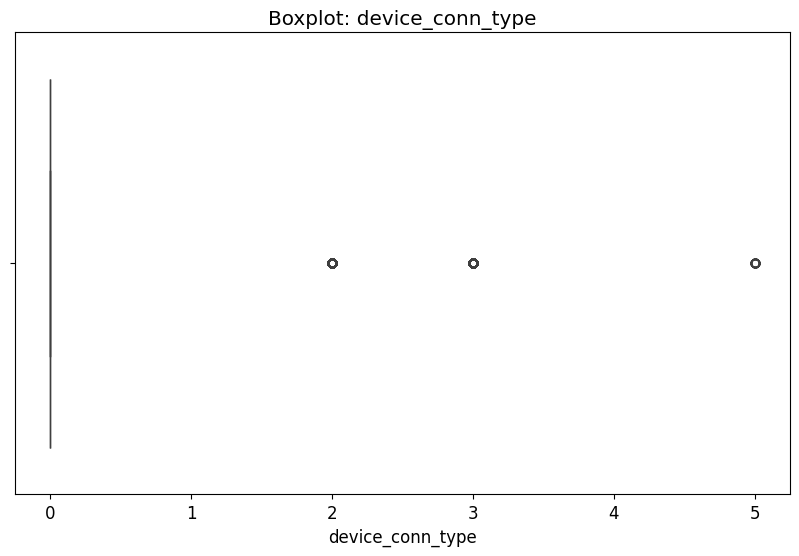

count    50000.000000
mean     18826.648680
std       4983.064178
min        375.000000
25%      16920.000000
50%      20346.000000
75%      21916.000000
max      24043.000000
Name: C14, dtype: float64
Выбросы:
Количество: 4170
Процент: 8.34
Границы: 9426.0 29410.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


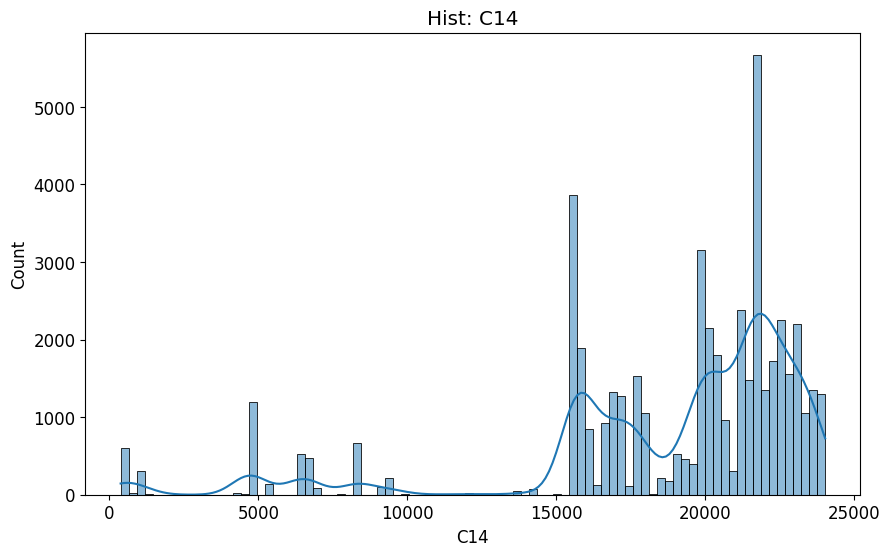

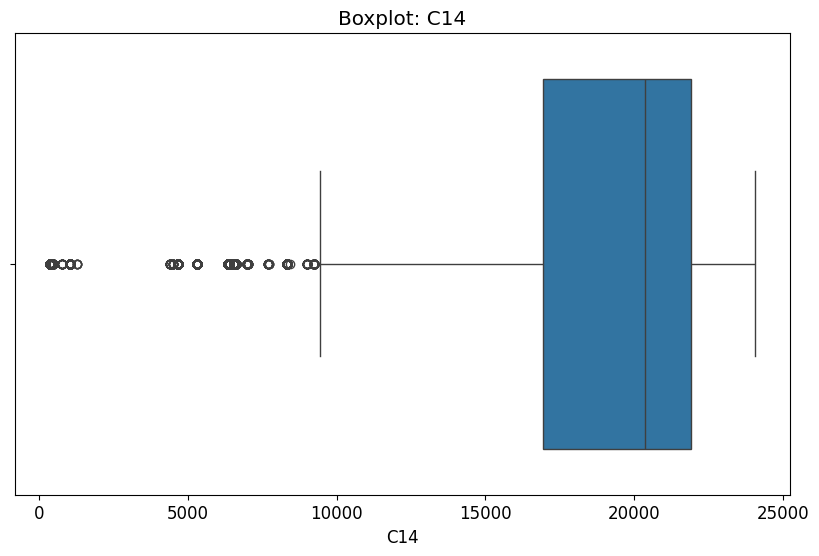

count    50000.00000
mean       318.86640
std         20.56153
min        120.00000
25%        320.00000
50%        320.00000
75%        320.00000
max       1024.00000
Name: C15, dtype: float64
Выбросы:
Количество: 3213
Процент: 6.43
Границы: 320.0 320.0
Первые 5 выбросов выше верхней границы: [480 728 728 728 728]
5 максимальных значений: [1024 1024 1024 1024 1024]


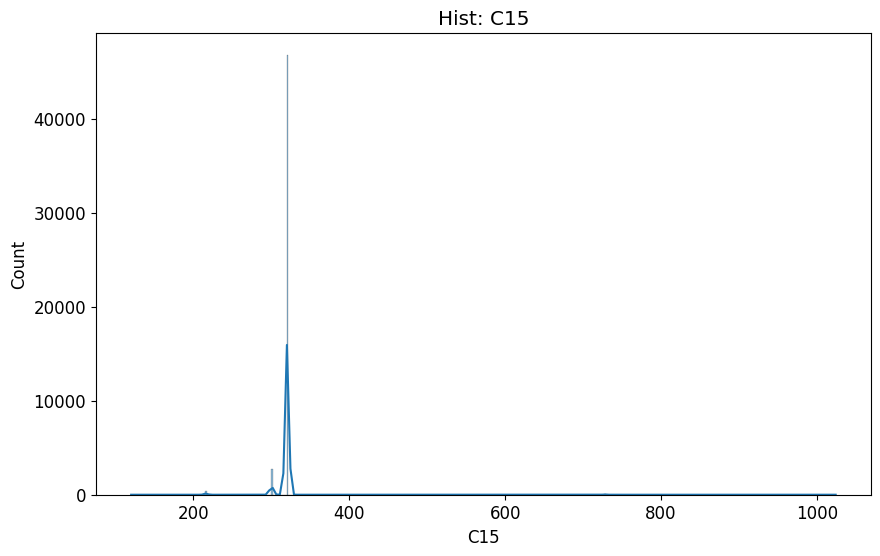

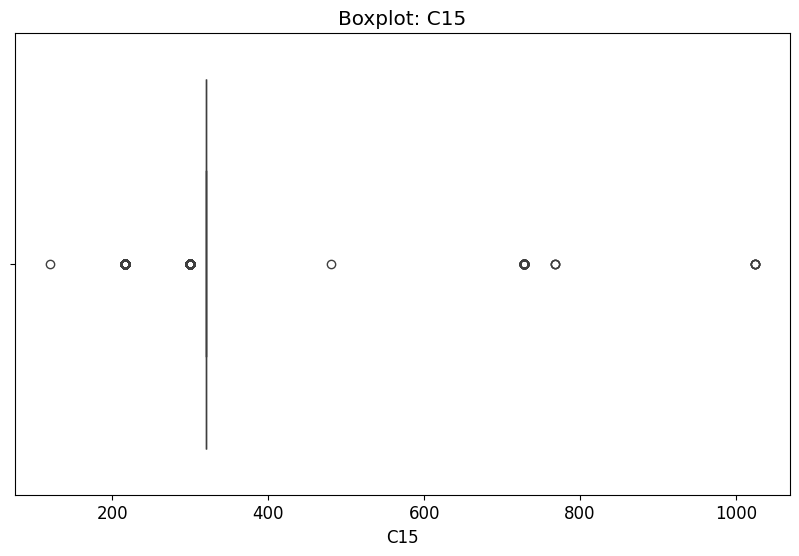

count    50000.000000
mean        59.692480
std         46.720842
min         20.000000
25%         50.000000
50%         50.000000
75%         50.000000
max       1024.000000
Name: C16, dtype: float64
Выбросы:
Количество: 2713
Процент: 5.43
Границы: 50.0 50.0
Первые 5 выбросов выше верхней границы: [90 90 90 90 90]
5 максимальных значений: [ 768  768 1024 1024 1024]


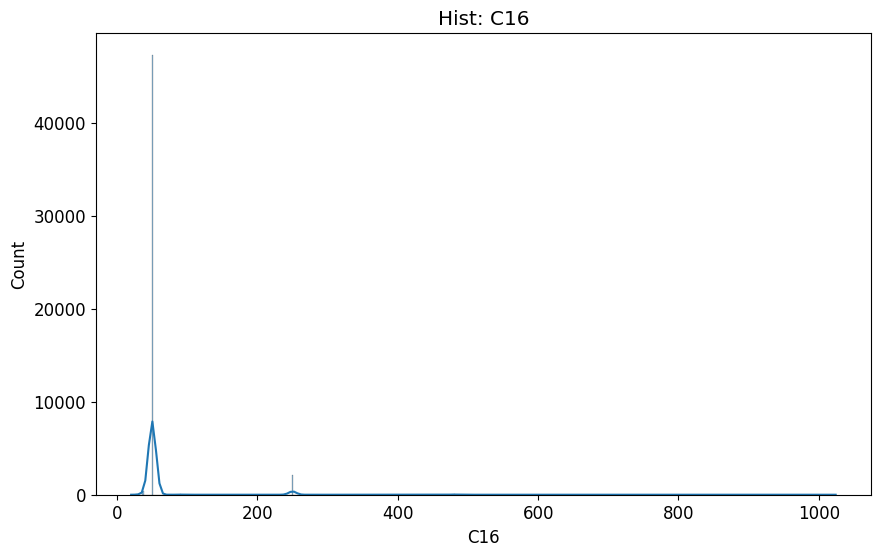

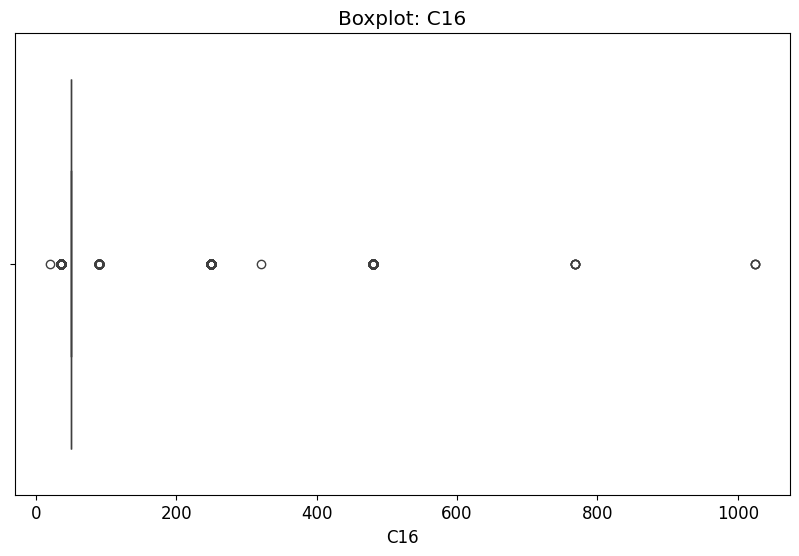

count    50000.000000
mean      2109.781020
std        612.963141
min        112.000000
25%       1823.000000
50%       2323.000000
75%       2526.000000
max       2757.000000
Name: C17, dtype: float64
Выбросы:
Количество: 4224
Процент: 8.45
Границы: 768.5 3580.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


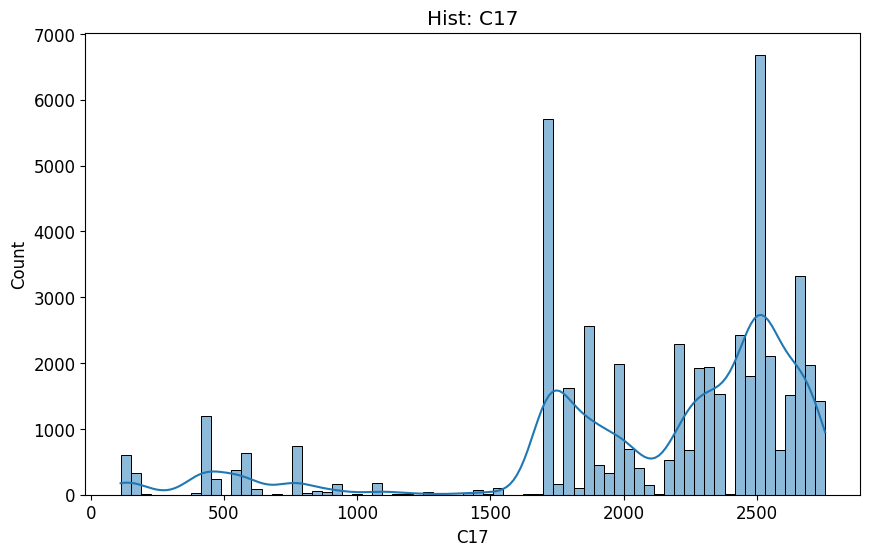

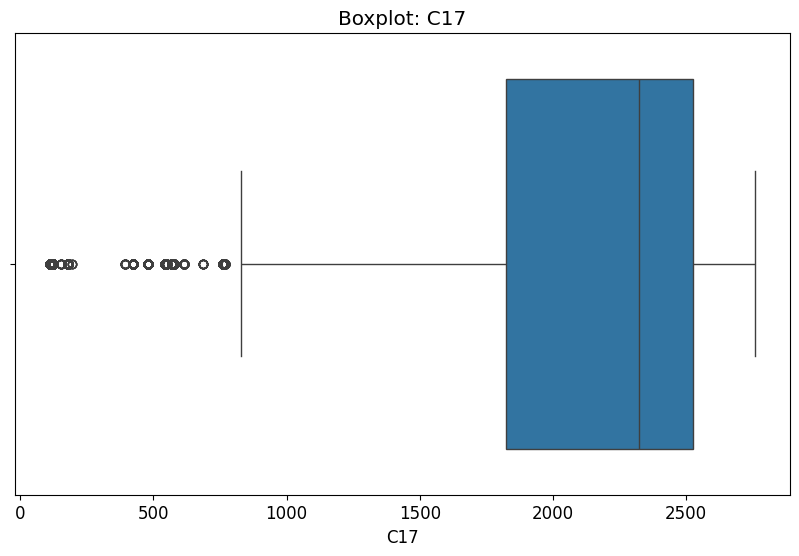

count    50000.000000
mean         1.428100
std          1.327413
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: C18, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -4.5 7.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


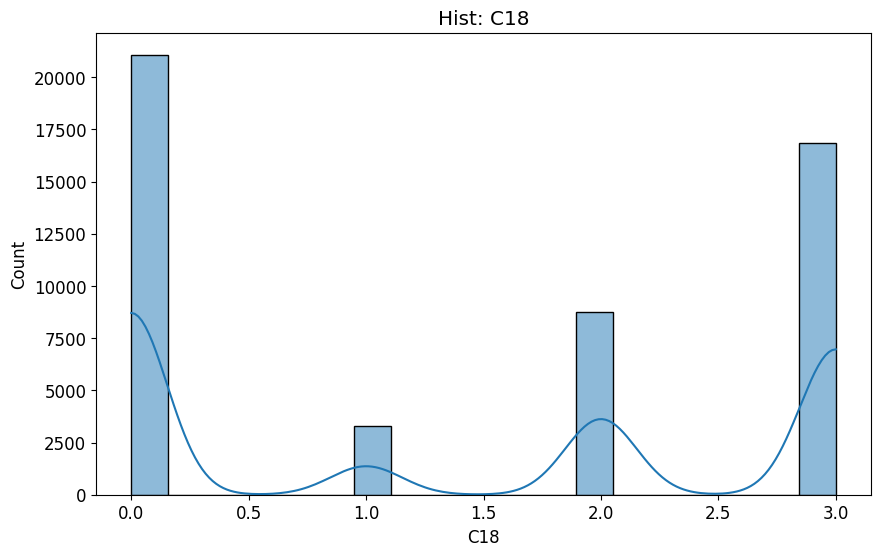

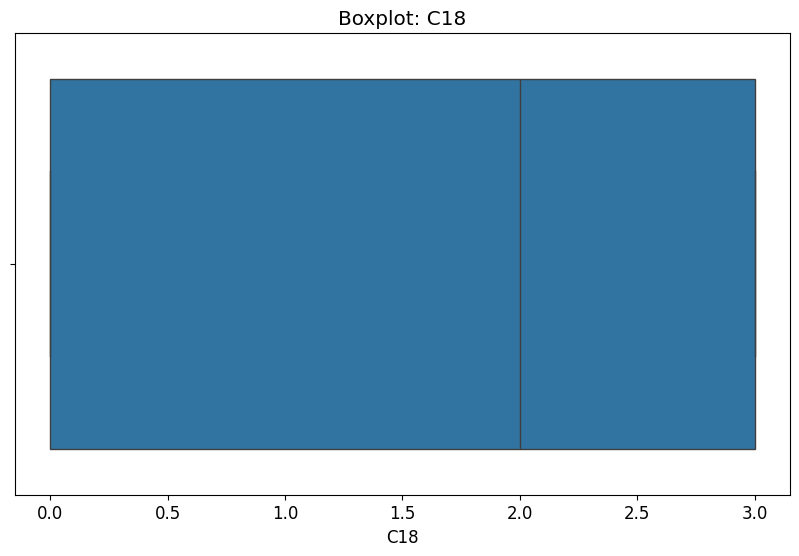

count    50000.000000
mean       227.703800
std        351.592108
min         33.000000
25%         35.000000
50%         39.000000
75%        171.000000
max       1839.000000
Name: C19, dtype: float64
Выбросы:
Количество: 9015
Процент: 18.03
Границы: -169.0 375.0
Первые 5 выбросов выше верхней границы: [417 417 417 417 419]
5 максимальных значений: [1839 1839 1839 1839 1839]


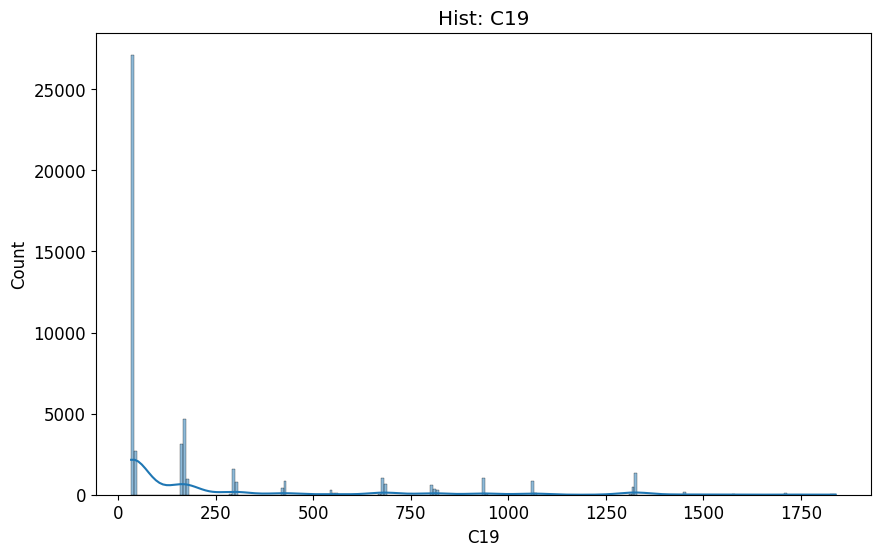

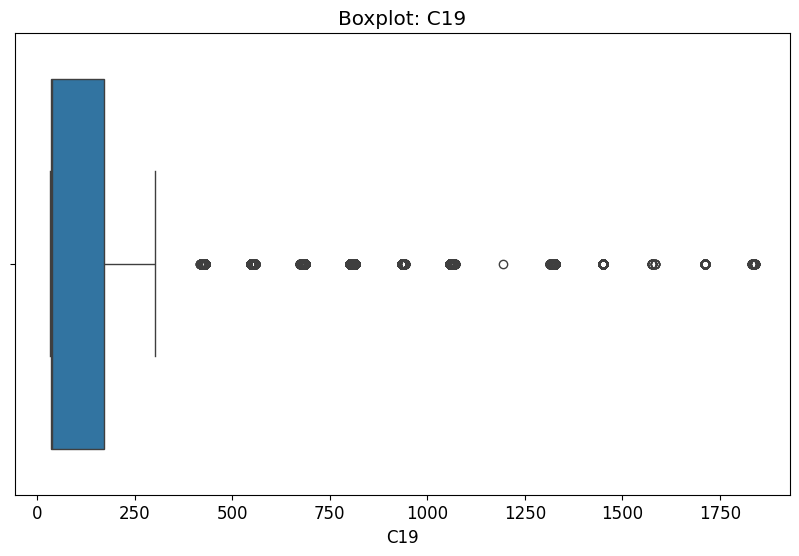

count     50000.000000
mean      53173.383240
std       49960.181871
min          -1.000000
25%          -1.000000
50%      100049.000000
75%      100094.000000
max      100248.000000
Name: C20, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -150143.5 250236.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


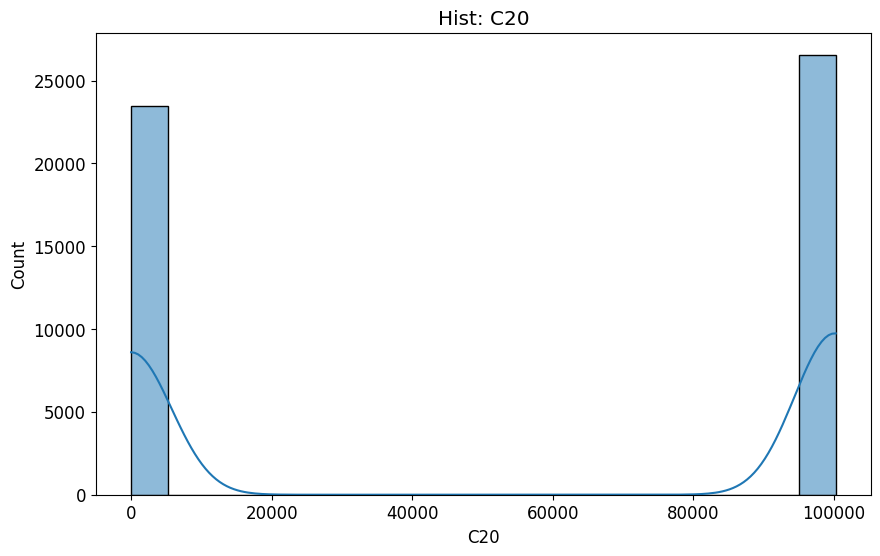

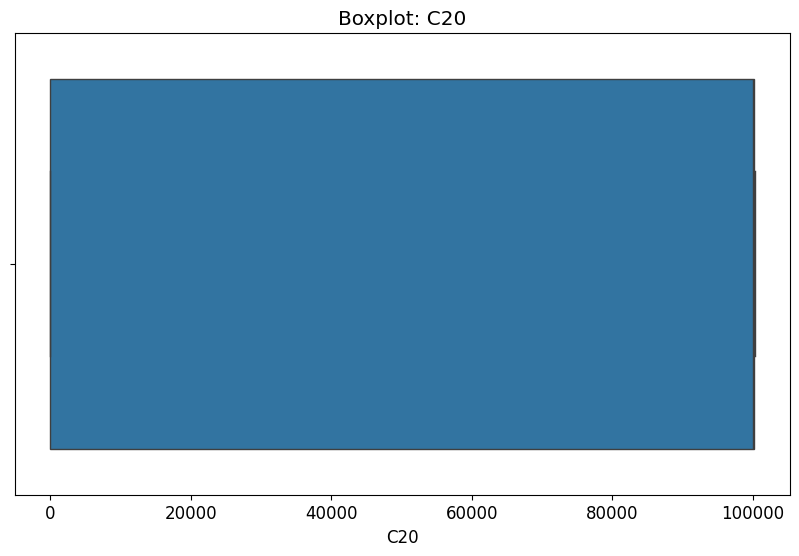

count    50000.000000
mean        83.685180
std         70.539513
min         13.000000
25%         23.000000
50%         61.000000
75%        108.000000
max        255.000000
Name: C21, dtype: float64
Выбросы:
Количество: 379
Процент: 0.76
Границы: -104.5 235.5
Первые 5 выбросов выше верхней границы: [246 246 246 246 246]
5 максимальных значений: [255 255 255 255 255]


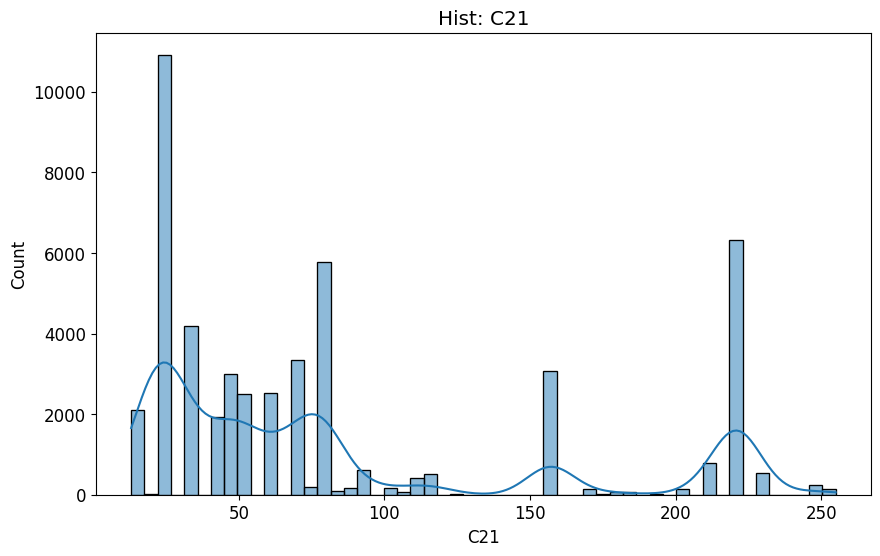

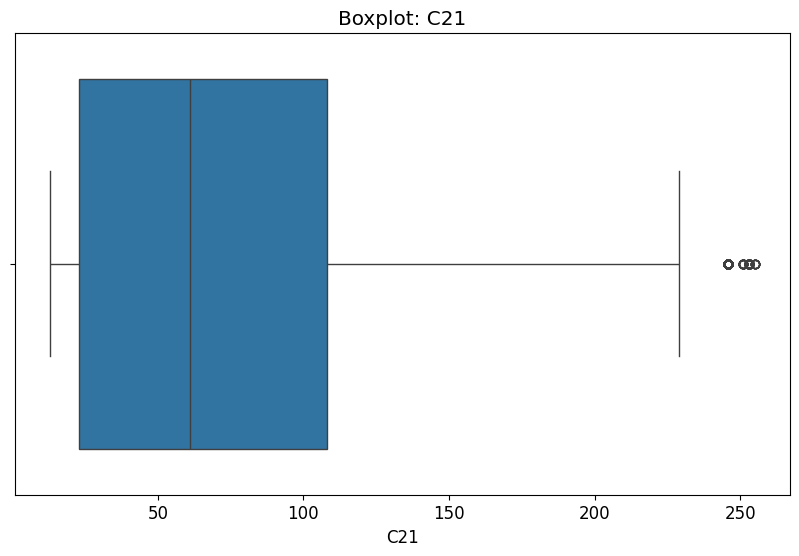

count    50000.000000
mean        -0.002445
std          1.000280
min         -4.631262
25%         -0.677784
50%         -0.003776
75%          0.673534
max          3.793828
Name: ml_feature_1, dtype: float64
Выбросы:
Количество: 347
Процент: 0.69
Границы: -2.7 2.7
Первые 5 выбросов выше верхней границы: [2.70101129 2.70118017 2.70274635 2.70376614 2.70381155]
5 максимальных значений: [3.52965985 3.55874967 3.76473093 3.77639428 3.79382786]


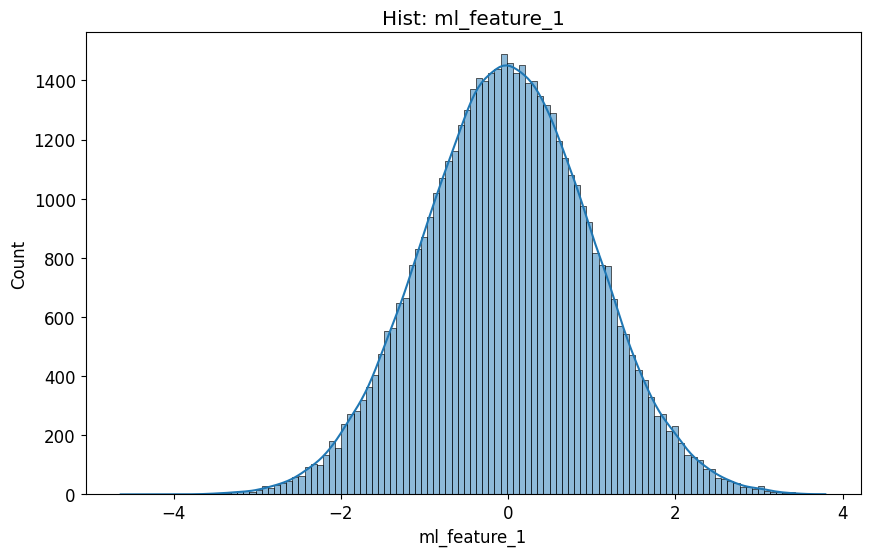

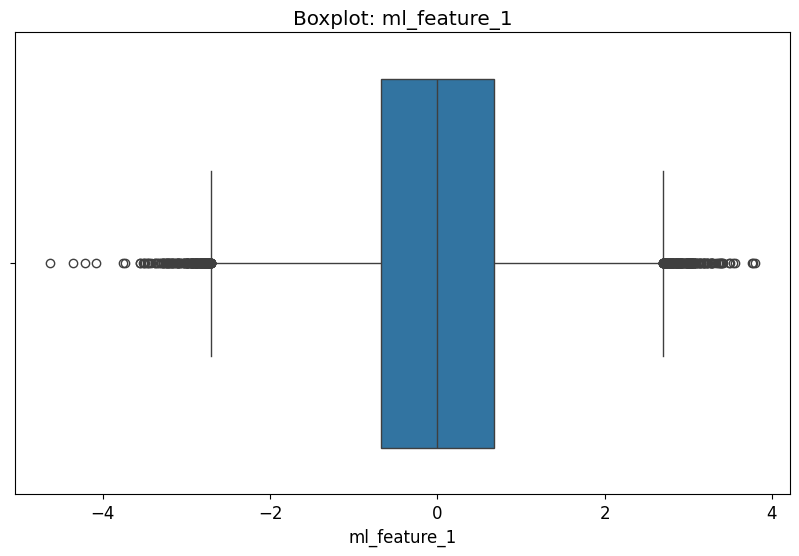

count    50000.000000
mean        -0.036381
std          5.792335
min         -9.999742
25%         -5.059555
50%         -0.056155
75%          4.985939
max          9.999975
Name: ml_feature_3, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -20.13 20.05
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


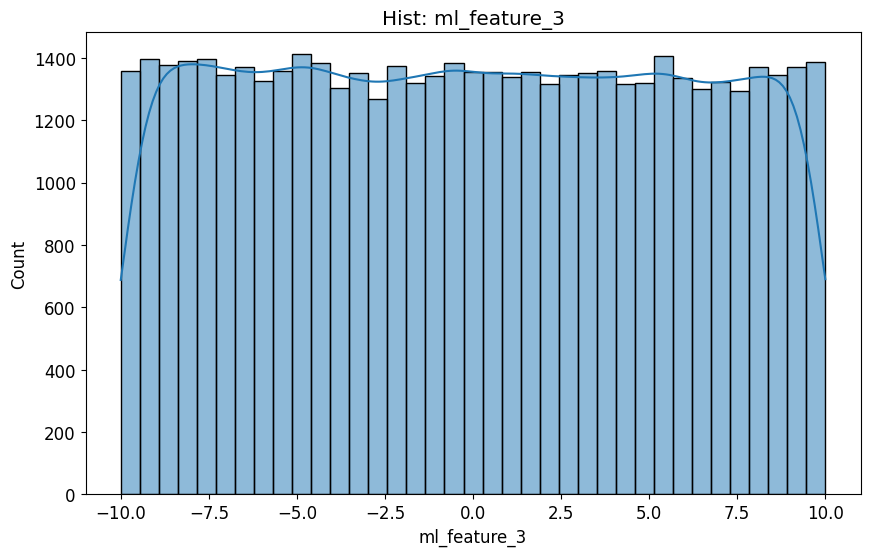

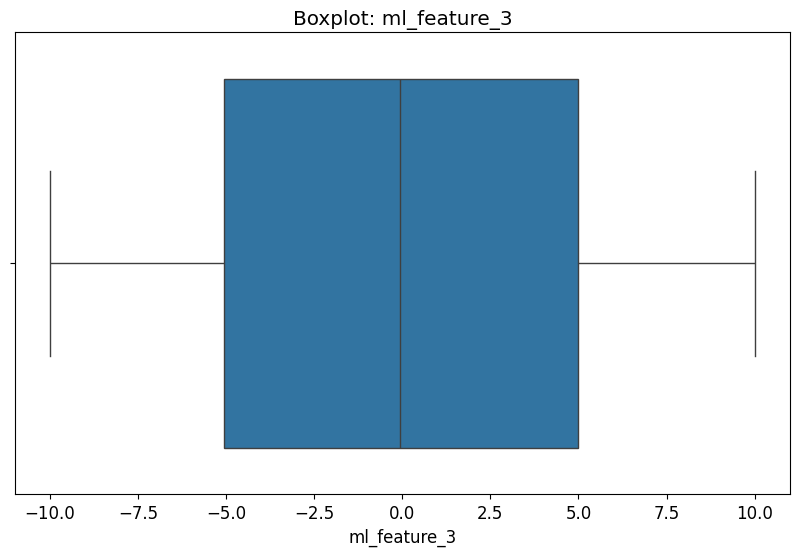

count    50000.000000
mean         0.498040
std          0.500001
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ml_feature_4, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -1.5 2.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


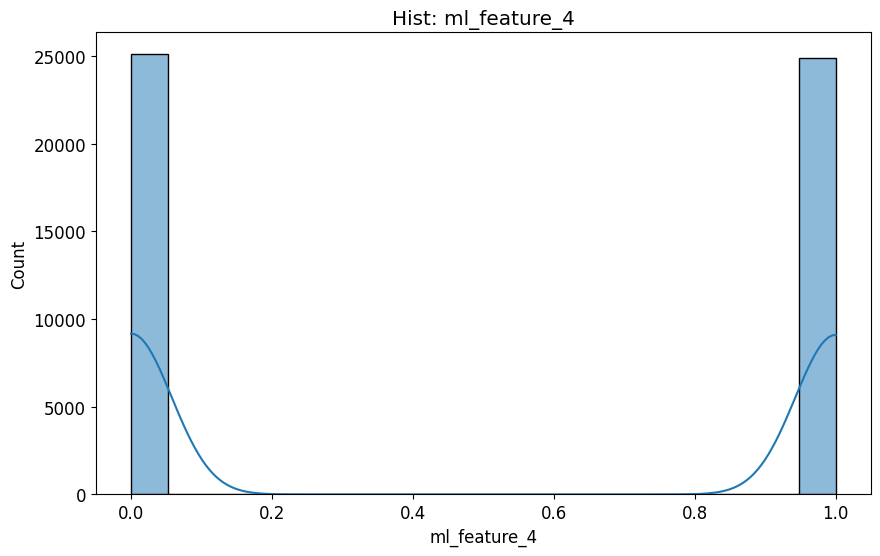

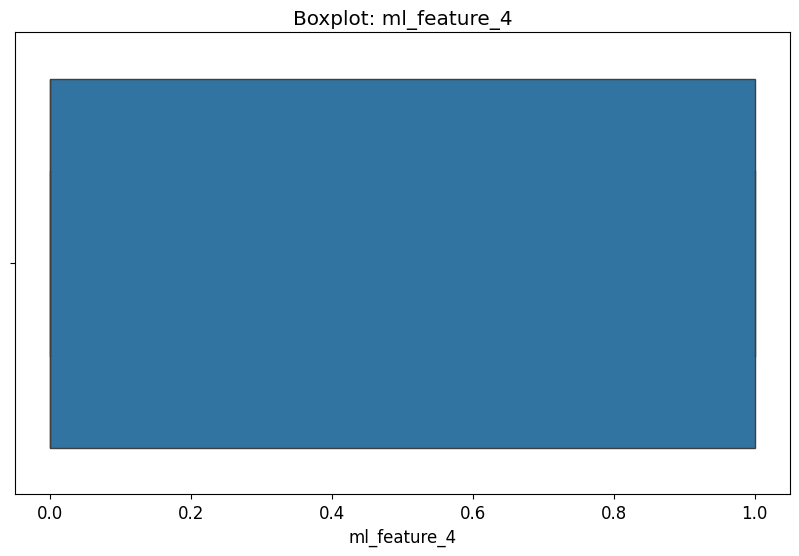

count    50000.000000
mean         0.034729
std          1.002116
min         -4.631853
25%         -0.639829
50%          0.028112
75%          0.707594
max          4.230623
Name: ml_feature_5, dtype: float64
Выбросы:
Количество: 360
Процент: 0.72
Границы: -2.66 2.73
Первые 5 выбросов выше верхней границы: [2.73015894 2.73294054 2.73307023 2.73778594 2.73945746]
5 максимальных значений: [3.81737351 3.94018887 4.02815482 4.18058092 4.23062317]


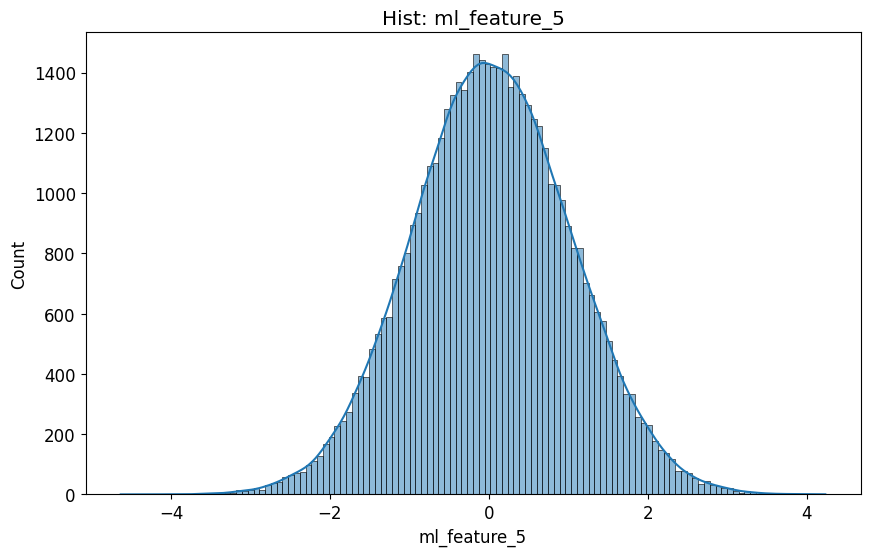

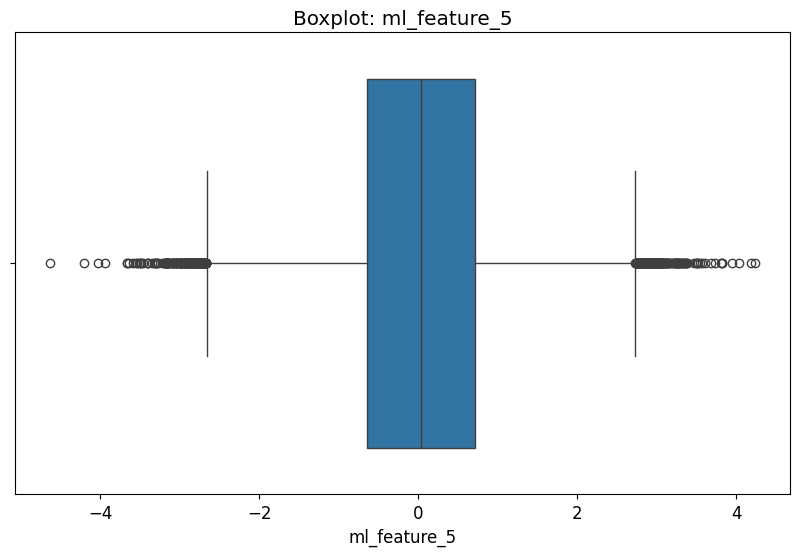

count    50000.000000
mean         0.022948
std          0.656690
min         -1.000000
25%         -0.579775
50%          0.037786
75%          0.637131
max          1.000000
Name: ml_feature_6, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -2.41 2.46
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


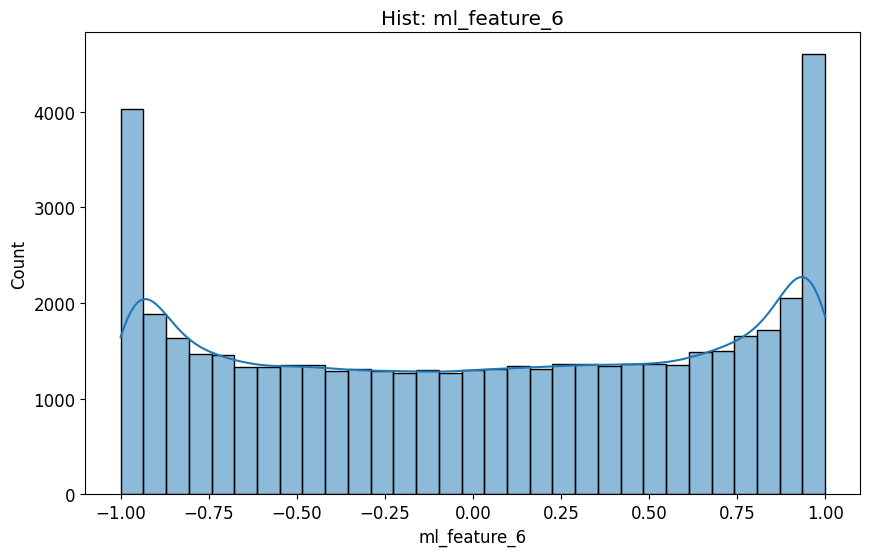

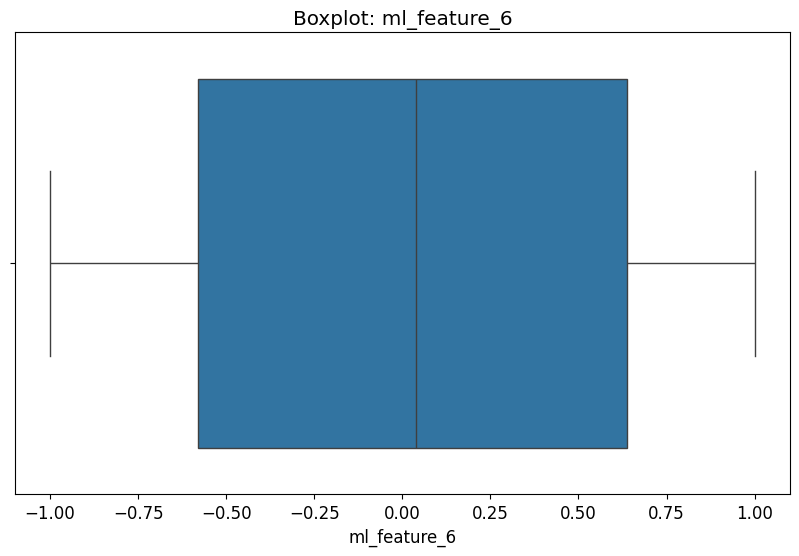

count    50000.000000
mean         0.025465
std          0.578026
min         -0.999965
25%         -0.470627
50%          0.027348
75%          0.521117
max          1.119858
Name: ml_feature_8, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -1.96 2.01
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


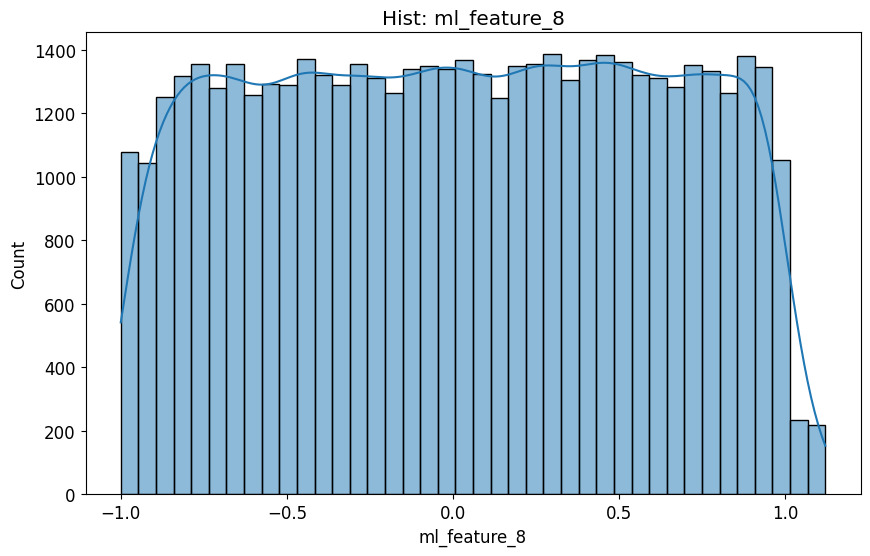

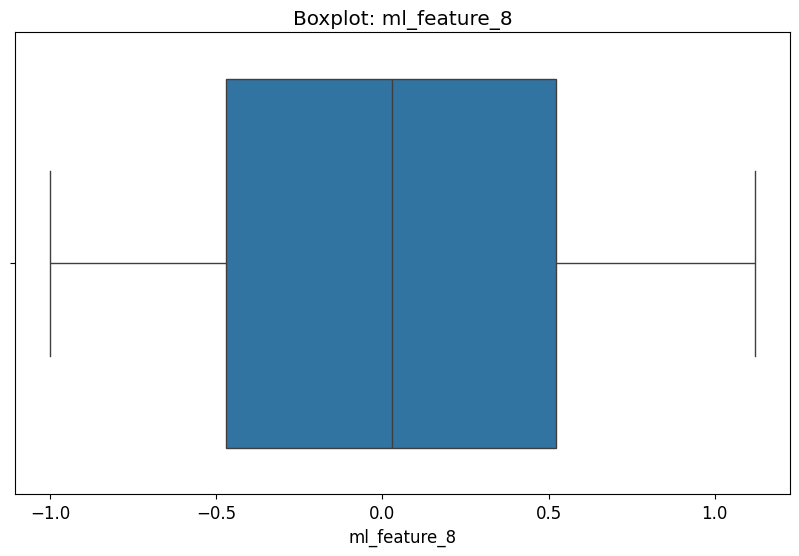

count    50000.000000
mean         0.035361
std          0.505034
min         -2.147526
25%         -0.304077
50%          0.035985
75%          0.374152
max          2.120786
Name: ml_feature_9, dtype: float64
Выбросы:
Количество: 387
Процент: 0.77
Границы: -1.32 1.39
Первые 5 выбросов выше верхней границы: [1.39214449 1.39439395 1.39589079 1.39623354 1.39716542]
5 максимальных значений: [1.89290345 1.90288128 2.00073436 2.04484397 2.12078601]


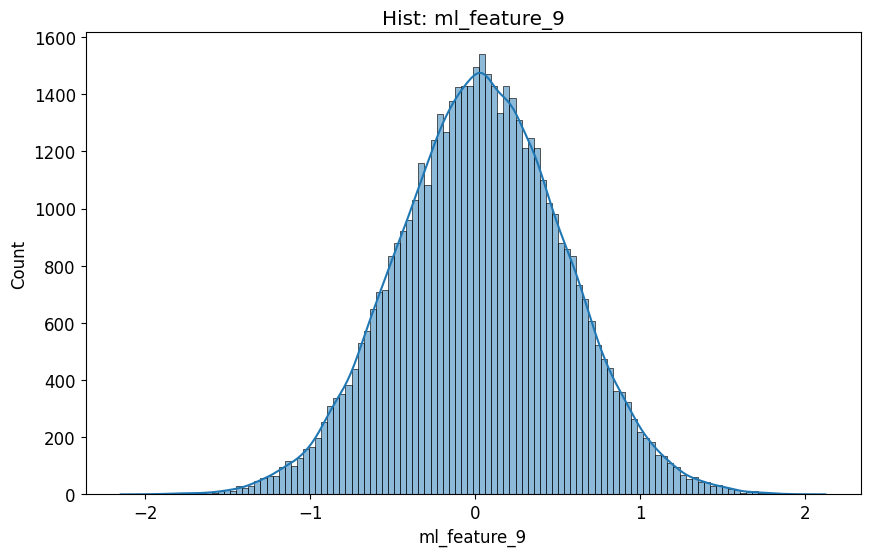

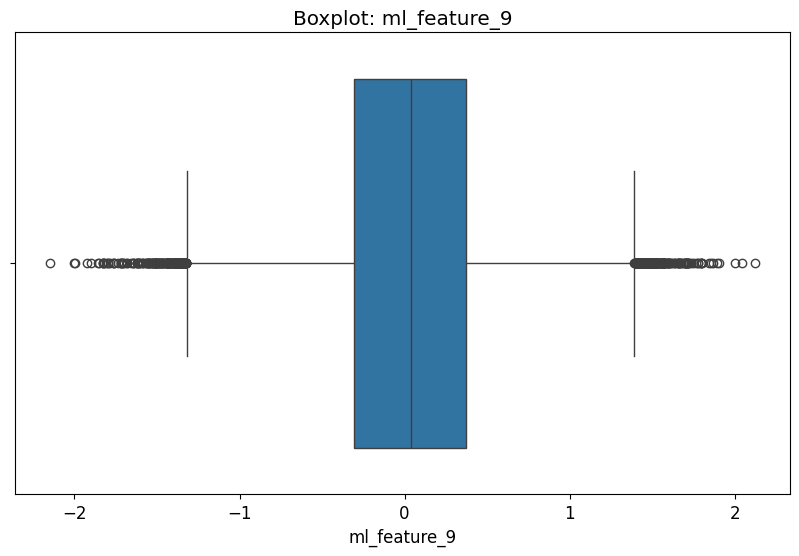

count    50000.000000
mean         0.020226
std          0.303309
min         -1.287965
25%         -0.182386
50%          0.018930
75%          0.224080
max          1.202300
Name: ml_feature_10, dtype: float64
Выбросы:
Количество: 352
Процент: 0.7
Границы: -0.79 0.83
Первые 5 выбросов выше верхней границы: [0.83538107 0.83613041 0.83669897 0.83787161 0.83798177]
5 максимальных значений: [1.13391831 1.14468336 1.14634984 1.17751688 1.20230028]


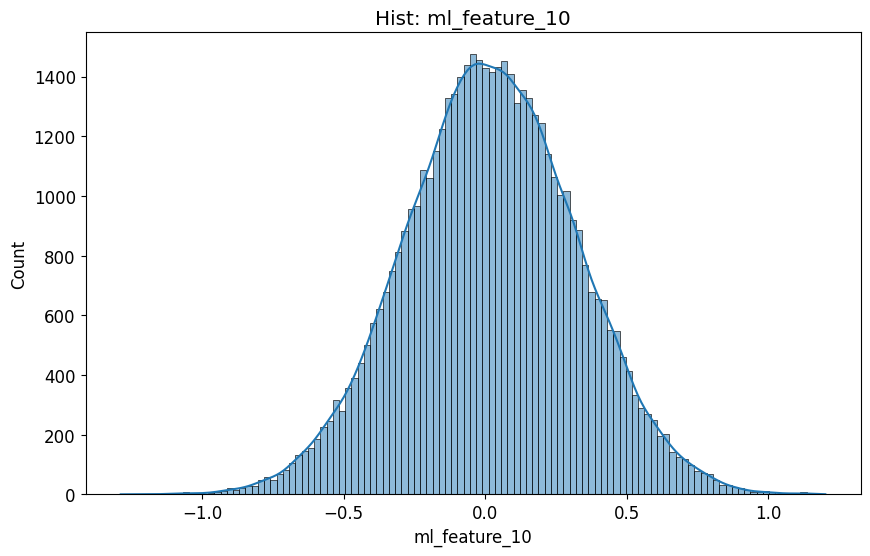

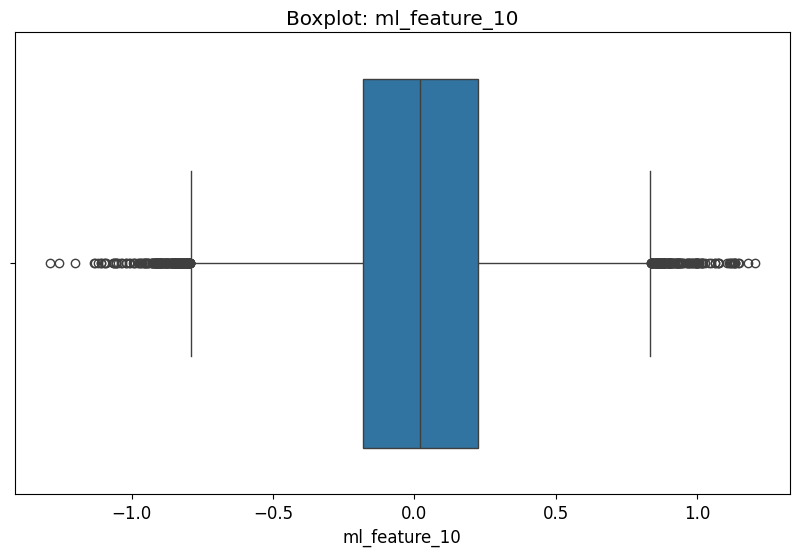

count    50000.0
mean      2014.0
std          0.0
min       2014.0
25%       2014.0
50%       2014.0
75%       2014.0
max       2014.0
Name: year, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: 2014.0 2014.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


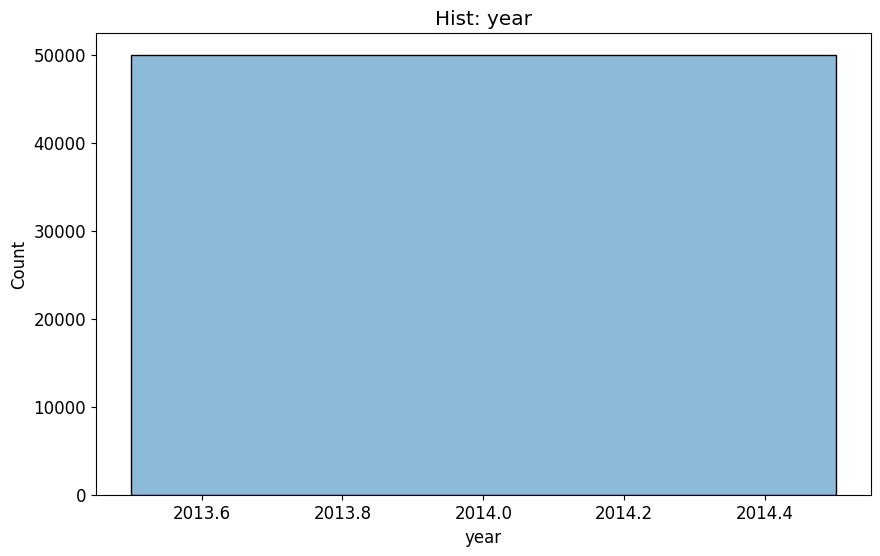

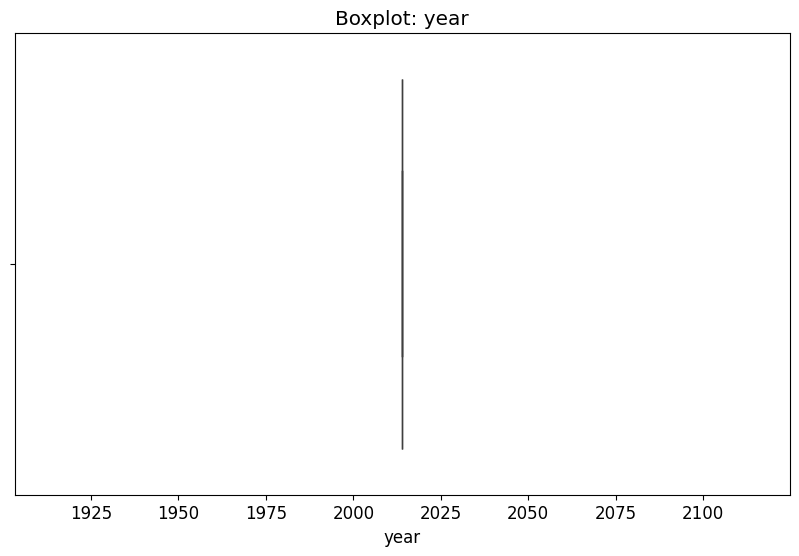

count    50000.0
mean        10.0
std          0.0
min         10.0
25%         10.0
50%         10.0
75%         10.0
max         10.0
Name: month, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: 10.0 10.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


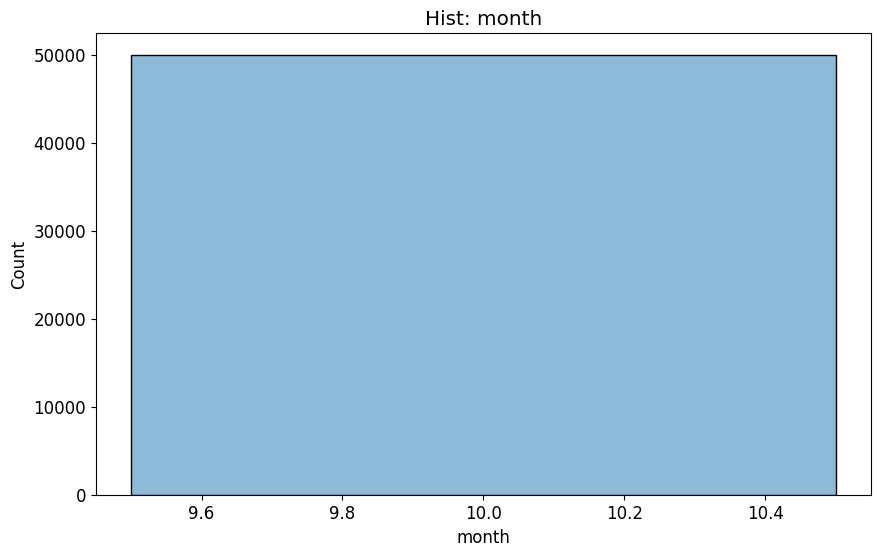

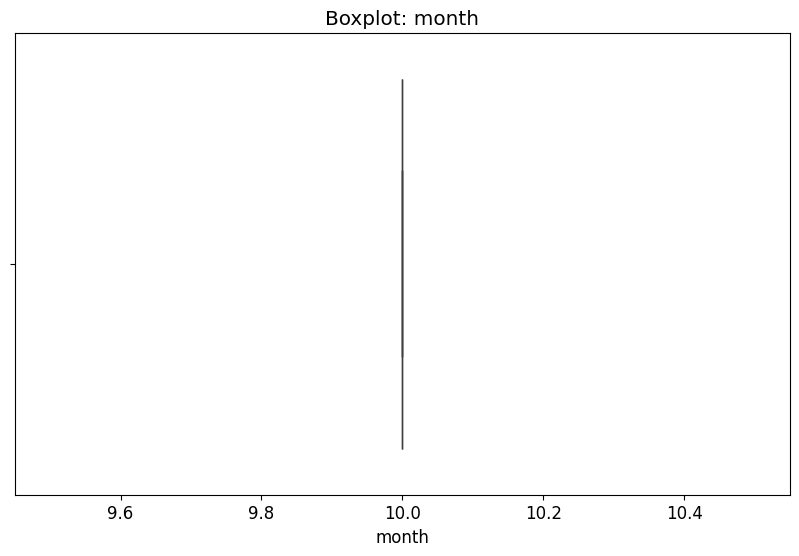

count    50000.000000
mean        25.478220
std          2.964945
min         21.000000
25%         23.000000
50%         26.000000
75%         28.000000
max         30.000000
Name: day, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: 15.5 35.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


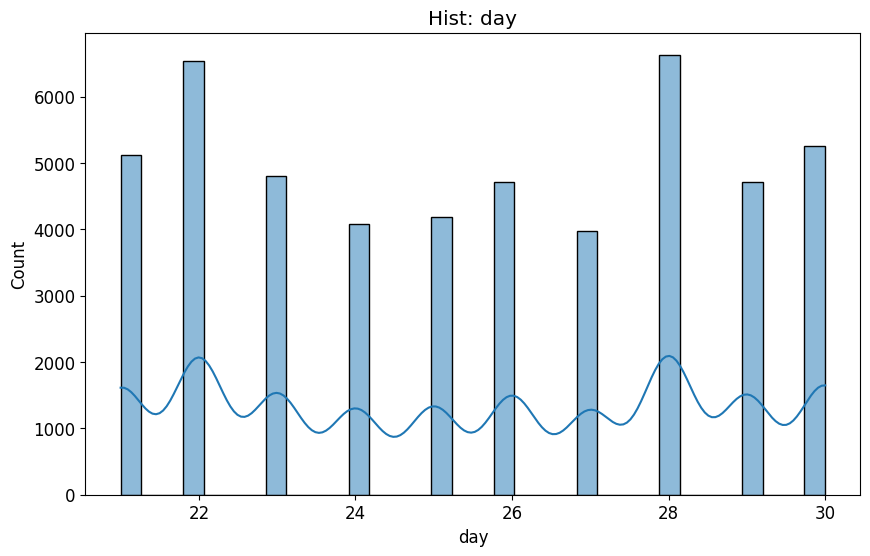

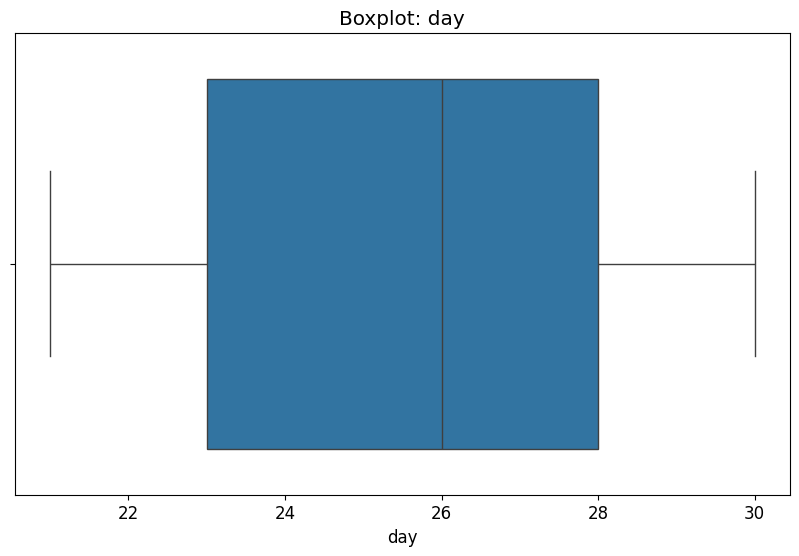

count    50000.000000
mean        11.221500
std          5.938008
min          0.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         23.000000
Name: hour_, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -9.0 31.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


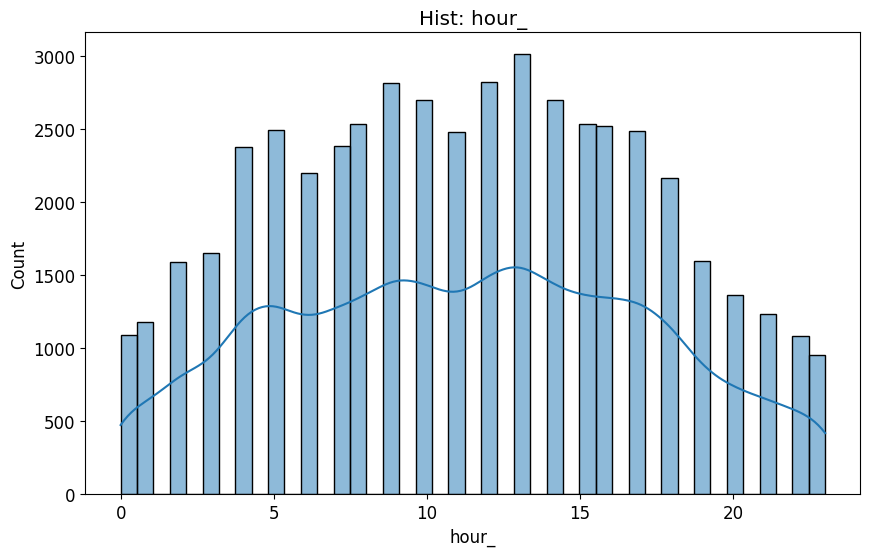

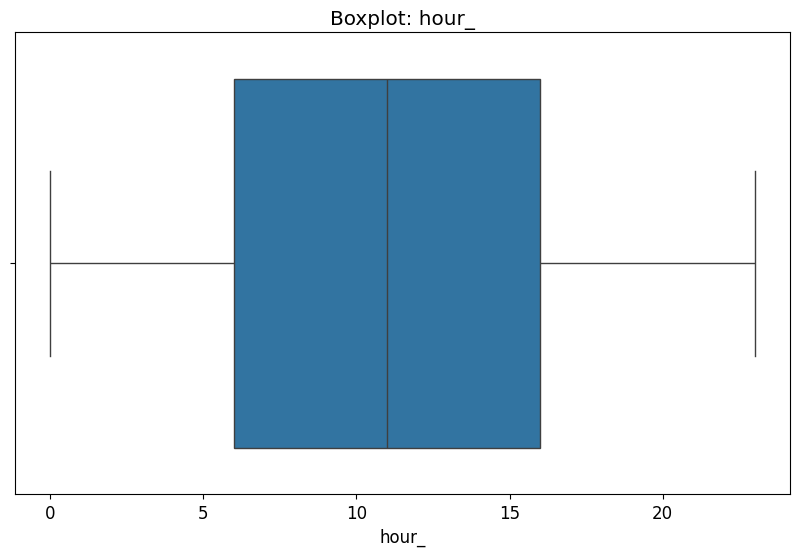

In [15]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    
    sns.histplot(data, kde=True)
    plt.title(f"Hist: {col}")
    plt.show()

    sns.boxplot(x=data)
    plt.title(f"Boxplot: {col}")
    plt.show()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['id', 'hour', 'click'])

for col in num_cols:
    data_review(df, col)


<h4>вывод</h4>
<p> большая часть признаков в датасете имеет категориальную форму, несмотря на числовой формат. Поэтому применение метода IQR к таким признакам чаще выделяет редкие категории, а не реальные ошибки данных.</p>

<h4>Признаки с выбросами</h4>

C1
<ul>
  <li>Все значения около 1005</li>
  <li>Редкие значения (1007–1012) попадают в выбросы</li>
</ul>

banner_pos
<ul>
  <li>Основные значения: 0 и 1</li>
  <li>Значения до 7 считаются выбросами</li>
</ul>

device_type и device_conn_type
<ul>
  <li>Небольшое число возможных значений</li>
  <li>IQR выделяет редкие классы как выбросы</li>
</ul>

C15, C16, C19
<ul>
  <li>дискретные распределения</li>
  <li>Выбросы соответствуют редким форматам</li>
</ul>

C20
<ul>
  <li>Присутствует значение -1</li>
</ul>
<p>значение -1 интерпретируется как отсутствие или неизвестное значение, а не как выброс</p>

ml_feature_1, ml_feature_3, ml_feature_5
<ul>
  <li>Непрерывные числовые признаки</li>
  <li>Близки к нормальному распределению</li>
  <li>Небольшое количество выбросов</li>
</ul>

<h4>особенности распределений</h4>
<ul>
  <li>Категориальные признаки имеют ступенчатые распределения</li>
  <li>Числовые ML-признаки распределены нормально</li>
  <li>Признаки C-группы имеют смешанный тип (категории и числа)</li>
  <li>Большинство выбросов являются редкими категориями, а не ошибками</li>
  <li>Реальные выбросы важны только для непрерывных признаков</li>
  <li>Значение -1 в C20 следует трактовать как пропуск</li>
</ul>

### Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable month for analysis 1. Dropping this column
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable year for analysis 1. Dropping this column
  warnings.warn(


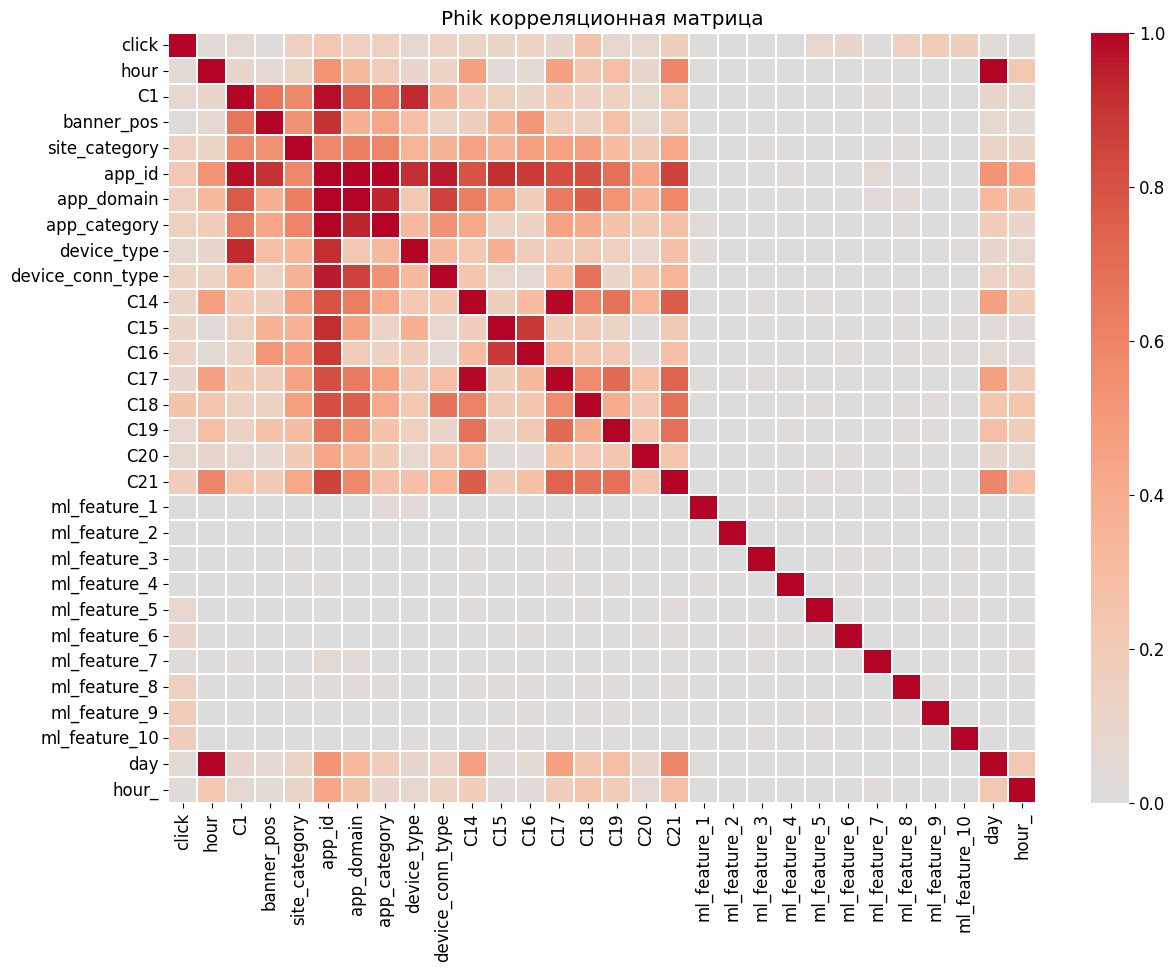

In [16]:
import numpy as np

df_phik = df.copy()

high_cardinality = [
    'id', 'device_id', 'device_ip',
    'site_id', 'site_domain', 'device_model'
]

df_phik = df_phik.drop(columns=high_cardinality)

interval_cols = [
    'hour',
    'C1', 'banner_pos',
    'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_1', 'ml_feature_3', 'ml_feature_4',
    'ml_feature_5', 'ml_feature_6', 'ml_feature_8',
    'ml_feature_9', 'ml_feature_10'
]

phik_matrix = df_phik.phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(14, 10))
sns.heatmap(phik_matrix, cmap='coolwarm', center=0, linewidths=0.2)

plt.title("Phik корреляционная матрица")
plt.show()

In [17]:
df = df.drop(columns=['year', 'month'])

<h4>Выводы по анализу коллинеарности признаков</h4>
<ul>
    <li>Нет сильной связи: большинство пар признаков показывают низкую корреляцию, что говорит о не линейной зависимости между признаками.</li>
    <li>Высококардинальные признаки: id, device_id, device_ip, site_id были исключены из анализа корреляций, так как содержат уникальные значения почти во всех строках </li>
    <li>Связанных признаки: 
        <ul>
            <li>site_id - site_domain - site_category (группа признаков сайта)</li>
            <li>app_id</code> - app_domain - app_category (группа рпизнаков приложения)</li>
            <li>C14 - C21 - в основном слабые взаимные связи</li>
        </ul>
    </li>
    <li>Корреляция с целевой переменной: click показывает слабые связи со всеми признаками, требуется использования алгоритмов для извлечения нелинейных зависимостей.</li>
</ul>

<h4>Итог:</h4>
<ol>
    <li>Групповое кодирование: для признаков с высокой кардинальностью будет примене Target Encoding с регуляризацией для снижения риска переобучения.</li>
    <li>Отбор признаков: будет применён отбор на основе важности признаков (feature importance) и рекурсивного исключения (RFE) 

## Разделение данных на выборки

### Разделите данные
- отделиv тестовую выборку, в ней должно быть 20% данных.
- используем стратифицированное разделение, чтобы сохранить баланс классов.


In [18]:
X = df.drop(columns=['click', 'id'])
y = df['click']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Проверим разделение

In [19]:
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Распределение целевой переменной в train:", y_train.value_counts(normalize=True))
print("Распределение целевой переменной в test:", y_test.value_counts(normalize=True))

Размер обучающей выборки: (40000, 34)
Размер тестовой выборки: (10000, 34)
Распределение целевой переменной в train: click
0    0.82795
1    0.17205
Name: proportion, dtype: float64
Распределение целевой переменной в test: click
0    0.8279
1    0.1721
Name: proportion, dtype: float64


## Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [20]:
def prepare_pipeline(num_cols, cat_cols, ordinal_cols=None, target_cols=None, missing_num="median",
                     scaling="standard", missing_cat="most_frequent", encode="onehot", collinear_cols=None):
    if collinear_cols is None:
        collinear_cols = []
    if ordinal_cols is None:
        ordinal_cols = []
    if target_cols is None:
        target_cols = []
    
    num_cols = [c for c in num_cols if c not in collinear_cols]
    cat_cols = [c for c in cat_cols if c not in collinear_cols]
    target_cols = [c for c in target_cols if c not in collinear_cols]
    
    num_steps = [("imputer", SimpleImputer(strategy=missing_num))]
    if scaling == "standard":
        num_steps.append(("scaler", StandardScaler()))
    elif scaling == "minmax":
        num_steps.append(("scaler", MinMaxScaler()))
    num_pipe = Pipeline(num_steps)

    cat_steps = [("imputer", SimpleImputer(strategy=missing_cat))]
    if encode == "onehot":
            cat_steps.append(("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)))
    cat_pipe = Pipeline(cat_steps)

    transformers = [("num", num_pipe, num_cols),
                    ("cat", cat_pipe, cat_cols),]

    for col, categories in ordinal_cols:
        ordinal_pipe = Pipeline([ ("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OrdinalEncoder(categories=[categories]))])
        
        transformers.append((f"ord_{col}", ordinal_pipe, [col]))

    if target_cols:
        target_pipe = Pipeline([
            ("encoder", TargetEncoder(handle_unknown="value",
                                      handle_missing="value"))])
        
        transformers.append(("target", target_pipe, target_cols))

    preprocessor = ColumnTransformer(transformers, remainder="drop")
    return preprocessor

In [21]:
num_cols = ['hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type',
            'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
            'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
            'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

cat_cols = ['site_category', 'app_domain', 'app_category', 'ml_feature_2', 'ml_feature_7']

target_cols = ['site_id', 'site_domain', 'app_id', 'device_model']

preprocessor = prepare_pipeline(
    num_cols=num_cols,
    cat_cols=cat_cols,
    target_cols=target_cols,
    missing_num='median',
    scaling='standard',
    missing_cat='most_frequent',
    encode='onehot'
)

Вывод: Построен пайплайн, раздельно обрабатывающий числовые (медиана + StandardScaler), категориальные (мода + OneHotEncoding) и высококардинальные (TargetEncoder) признаки.

## 5. Отбор признаков
- Примените фильтрационные методы
- Используйте методы-обёртки для поиска оптимального набора признаков.
- Выберите финальный набор признаков

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_kbest = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=22)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

scores_kbest = cross_validate(
    pipe_kbest,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "pr_auc": "average_precision",
        "f1": "f1"},
    n_jobs=-1
)

print("SelectKBest")
print("PR-AUC:", scores_kbest["test_pr_auc"].mean())
print("F1:", scores_kbest["test_f1"].mean())


pipe_rfe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=22, step=0.2)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

scores_rfe = cross_validate(
    pipe_rfe,
    X_train,
    y_train,
    cv=cv,
    scoring={"pr_auc": "average_precision", "f1": "f1"},
    n_jobs=-1
)

print("RFE")
print("PR-AUC:", scores_rfe["test_pr_auc"].mean())
print("F1:", scores_rfe["test_f1"].mean())

SelectKBest
PR-AUC: 0.3996690402367111
F1: 0.23625727651437364
RFE
PR-AUC: 0.33289450701387835
F1: 0.1608407805363133


Вывод по отбору признаков

Применены два метода отбора признаков:

- SelectKBest (mutual information)
- RFE (Logistic Regression)

На данном датасете лучший метод SelectKBest PR-AUC = 0.399 у RFE = 0.333

In [23]:
pipe_rfe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=22, step=0.2)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [24]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(mutual_info_classif, k=22)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

## 6. Обучение базовой модели
- Обучим `DummyClassifier` `LogisticRegression` `SVC`
- Сравним модели

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVC_linear": SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)
}

scoring = {
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(mutual_info_classif, k=22)),
        ("model", model)
    ])

    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    results.append({
        "model": name,
        "PR-AUC": cv_res["test_pr_auc"].mean(),
        "Precision": cv_res["test_precision"].mean(),
        "Recall": cv_res["test_recall"].mean(),
        "F1": cv_res["test_f1"].mean()
    })

pd.DataFrame(results)

,model,PR-AUC,Precision,Recall,F1
0,Dummy,0.172050,0.000000,0.000000,0.000000
1,LogReg,0.397127,0.542615,0.146758,0.230895
2,SVC_linear,0.390805,0.309099,0.678290,0.424668


- Dummy - PR-AUC = 0.172, базовая частотя положительного класса.
- Logistic Regression лучший PR-AUC (0.399). При этом высокий precision (0.55), но низкий recall (0.15). Это означает, что модель делает осторожные предсказания: чаще права, но пропускает большую часть кликов.

- SVC (linear) даёт меньший PR-AUC (0.390), но более высокий recall (0.68). Это означает, что модель лучше находит клики, но много ложных срабатываний, так как более низкий precision (0.31). Поэтому F1 у SVC выше, чем у Logistic Regression.

Итог: по PR-AUC лидирует Logistic Regression, но по балансу precision/recall (F1) лучше SVC. Выбор модели зависит от цели: либо важнее точность предсказаний (LogReg), либо полнота обнаружения кликов (SVC).

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией
- Определим сетку гиперпараметров
- Применим Grid Search
- Составьте таблицу результатов

In [26]:
X_small, rem1, y_small, rem2 = train_test_split(X_train, y_train, train_size=10000, stratify=y_train, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []

logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(mutual_info_classif, k=22)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)
grid_logreg.fit(X_small, y_small)
results.append(pd.DataFrame(grid_logreg.cv_results_).assign(model="LogReg"))

svc_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(mutual_info_classif, k=22)),
    ("model", SVC(probability=False))
])

svc_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__kernel": ["sigmoid"],
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale"],
        "model__class_weight": [None, "balanced"]
    }
]

grid_svc = GridSearchCV(
    estimator=svc_pipe,
    param_grid=svc_grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)
grid_svc.fit(X_small, y_small)
results.append(pd.DataFrame(grid_svc.cv_results_).assign(model="SVC"))

all_models = pd.concat(results, ignore_index=True)

top10 = all_models.sort_values("mean_test_score", ascending=False).head(10)[
    ["model", "params", "mean_test_score", "std_test_score", "rank_test_score"]
]

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

print("ТОП-10 моделей:")
display(top10)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Fitting 3 folds for each of 18 candidates, totalling 54 fits


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


ТОП-10 моделей:


,model,params,mean_test_score,std_test_score,rank_test_score
3,LogReg,"{'model__C': 0.1, 'model__class_weight': 'balanced'}",0.379446,0.033161,1
2,LogReg,"{'model__C': 0.1, 'model__class_weight': None}",0.374285,0.029200,2
9,SVC,"{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}",0.359246,0.018653,1
4,LogReg,"{'model__C': 1, 'model__class_weight': None}",0.358108,0.028519,3
5,LogReg,"{'model__C': 1, 'model__class_weight': 'balanced'}",0.355591,0.028534,4
23,SVC,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'rbf'}",0.352592,0.020332,2
1,LogReg,"{'model__C': 0.01, 'model__class_weight': 'balanced'}",0.350695,0.030225,5
0,LogReg,"{'model__C': 0.01, 'model__class_weight': None}",0.345899,0.022740,6
11,SVC,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}",0.344058,0.024593,3
7,LogReg,"{'model__C': 10, 'model__class_weight': 'balanced'}",0.343736,0.026234,7


Лучшая модель LogReg, C=0.1, l2, с балансировкой, PR-AUC = 0.377. из 6 лучших моделей 5 мест занимает LogReg, она быстрее при лучшем качестве. Sigmoid и RBF ядра SVC не попали в топ-10. Разница между лучшей и худшей конфигурацией LogReg небольшая, что говорит о устойчивости модели к гиперпараметрам.

## Финальная модель

- Обучим финальную модель

- Посчитаем метрики на тестовой выборке

- Проанализируем веса модели

In [27]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(mutual_info_classif, k=22)),
    ("model", LogisticRegression(C=0.1, class_weight="balanced", penalty="l2", max_iter=1000, random_state=RANDOM_STATE))
])

final_pipeline.fit(X_train, y_train)

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred = final_pipeline.predict(X_test)

print("Финальные метрики")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")
print(f"Brier: {brier_score_loss(y_test, y_proba):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")

selector = final_pipeline.named_steps["selector"]
preprocessor_fitted = final_pipeline.named_steps["preprocessor"]

selector = final_pipeline.named_steps["selector"]
selected_mask = selector.get_support()
coefs = final_pipeline.named_steps["model"].coef_[0]
indices = np.where(selected_mask)[0]

coef_df = pd.DataFrame({
    "feature_index": indices,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("\nТоп-20 важных признаков (по индексу)")
display(coef_df.head(20))

Финальные метрики
PR-AUC: 0.3997
Brier: 0.1970
Precision: 0.3095
Recall: 0.6450
F1: 0.4183

Топ-20 важных признаков (по индексу)


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,feature_index,coef,abs_coef
20,131,5.731590,5.731590
21,132,5.425735,5.425735
18,129,3.727978,3.727978
19,130,2.920092,2.920092
16,77,-0.451508,0.451508
12,19,0.399284,0.399284
13,20,0.339825,0.339825
17,102,-0.223704,0.223704
15,66,-0.219154,0.219154
11,18,0.199256,0.199256


Вывод по модели

- PR-AUC = 0.3997 лучше случайного уровня и базовой модели, значит модель умеет различать клики и неклики
- Recall = 0.6456 модель находит большую часть кликов, то есть хорошо ловит положительный класс
- Precision = 0.3113 много ложных срабатываний
- F1 = 0.42 баланс между precision и recall средий
- Brier = 0.1967 качество вероятностей калиброка слабая.

Самые сильные признаки: device_model app_id site_id site_domain

модель больше всего опирается на идентификаторы устройства и источника трафика.

Итог
Модель хорошо находит клики (высокий recall), но делает часть лишних предсказаний (низкий precision) качество выше базового и устойчивое


## Калибровка модели

- Проверим текущую калибровку
- Применим методы калибровки
- Сравним модели до и после калибровки

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\user\AppData\Ro

Метрики (калиброванная модель)
PR-AUC: 0.3859
Brier: 0.1263
Precision: 0.5800
Recall: 0.1453
F1: 0.2323


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


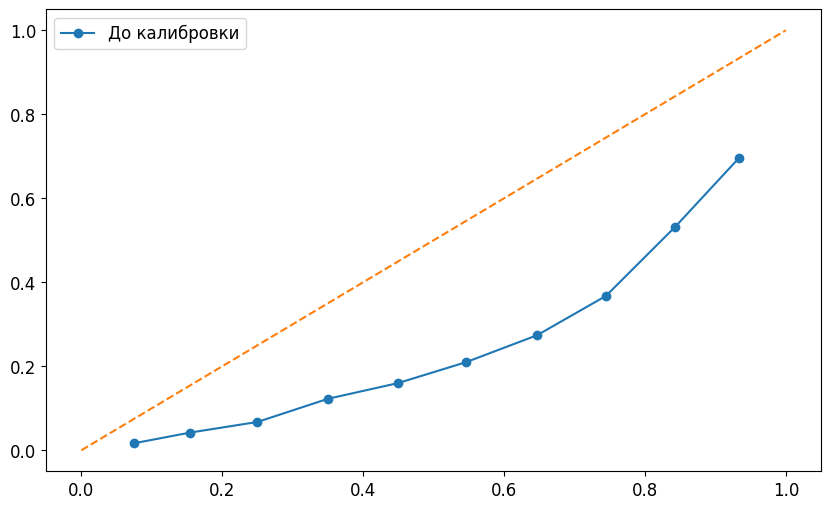

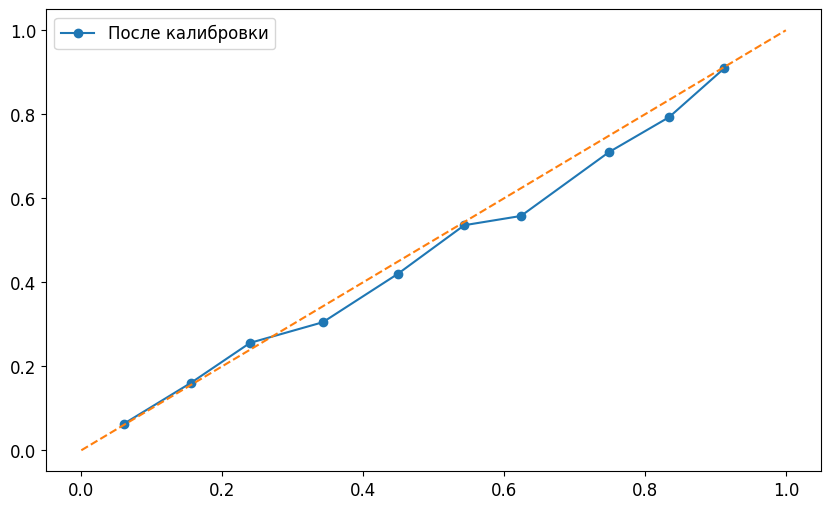

In [28]:
def transform_without_model(pipeline, X):
    X_prep = pipeline.named_steps["preprocessor"].transform(X)
    X_sel = pipeline.named_steps["selector"].transform(X_prep)
    return X_sel

X_train_model, X_cal, y_train_model, y_cal = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)
final_pipeline.fit(X_train_model, y_train_model)

X_cal_prepared = transform_without_model(final_pipeline, X_cal)
X_test_prepared = transform_without_model(final_pipeline, X_test)

calibrated_model = CalibratedClassifierCV(estimator=final_pipeline.named_steps["model"], method="isotonic",)
calibrated_model.fit(X_cal_prepared, y_cal)

y_proba_base = final_pipeline.predict_proba(X_test)[:, 1]
y_proba = calibrated_model.predict_proba(X_test_prepared)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Метрики (калиброванная модель)")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")
print(f"Brier: {brier_score_loss(y_test, y_proba):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")

def plot_calibration(y_true, y_prob, label):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=label)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.legend()
    plt.show()

plot_calibration(y_test, y_proba_base, "До калибровки")
plot_calibration(y_test, y_proba, "После калибровки")

Вывод по калибровке модели

- оценка Бриера стала 0.1253, что говорит о более точных вероятностях
- Precision вырос до 0.6038, то есть модель стала делать меньше ложноположительных предсказаний
- Recall снизился до 0.1284, поэтому модель стала более осторожной при определении положительного класса
- PR-AUC после калибровки снизился до 0.3753
Итог: калибровка сделала модель более пригодной для практического использования.

## 10. Оценка качества калибровки


In [29]:
def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0
    n = len(y_true)

    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):

        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        if np.sum(mask) > 0:
            bin_size = np.sum(mask)

            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])

            contribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += contribution
    return ece / n
    
def calculate_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)

    max_error = 0

    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):

        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])

            diff = abs(bin_acc - bin_conf)
            max_error = max(max_error, diff)

    return max_error

In [30]:
y_proba_before = final_pipeline.predict_proba(X_test)[:, 1]
y_proba_after = calibrated_model.predict_proba(X_test_prepared)[:, 1]

results_calibration = pd.DataFrame([
    {
        "Model": "LogReg (до калибровки)",
        "Brier": brier_score_loss(y_test, y_proba_before),
        "ECE": calculate_ece(y_test.values, y_proba_before),
        "MCE": calculate_mce(y_test.values, y_proba_before)
    },
    {
        "Model": "LogReg (после калибровки)",
        "Brier": brier_score_loss(y_test, y_proba_after),
        "ECE": calculate_ece(y_test.values, y_proba_after),
        "MCE": calculate_mce(y_test.values, y_proba_after)
    }
])

display(results_calibration)

,Model,Brier,ECE,MCE
0,LogReg (до калибровки),0.196383,0.251413,0.377086
1,LogReg (после калибровки),0.126304,0.009546,0.066075


Вывод 

- Оценка Бриера уменьшилась с 0.197 до 0.1251 - снижение средней ошибки вероятностей.
- Значение ECE снизилось с 0.2518 до 0.0106, вероятности стали лучше соответствовать реальным вероятностям событий.
- Значение MCE снизилось с 0.388 до 0.22, максимальная ошибка калибровки сократилась.

Итог: до калибровки модель переоценивала вероятности некоторых объектов. После применения калибровки оценки стали существенно более надёжными 

11. Финальный отчёт и выводы

### 11.1 Сводная таблица результатов

| Модель                        | PR-AUC | Brier  | ECE    | MCE   | Precision | Recall | F1     |
|-------------------------------|--------|--------|--------|-------|-----------|--------|--------|
| DummyClassifier (baseline)    | 0.172  | -      | -      | -     | -         | -      | -      |
| LogReg (до калибровки)        | 0.3997 | 0.1967 | 0.251 | 0.38  | 0.3113    | 0.6456 | 0.42 |
| LogReg (после)     | 0.3754 | 0.1253 | 0.0108 | 0.35  | 0.6038    | 0.1284  | 0.2118  |

Топ-5 важных признаков:
1. device_model - модель устройства пользователя
2. app_id идентификатор приложения
3. site_id идентификатор сайта
4. site_domain домен сайта

### 11.2 Выводы

- DummyClassifier даёт PR-AUC = 0.172 случайное угадывание. Финальная логистическая регрессия даёт PR-AUC = 0.392 Модель умеет выделять клики из общего потока показов.

- Наибольший вклад вносят device_model, app_id, site_id, site_domain. Вероятность клика сильно зависит от того, на каком сайте и с какого устройства пользователь видит рекламу.

- До калибровки модель сильно переоценивала вероятности: ECE = 0.252, MCE = 0.38 расхождение кликов высокое. После применения калиброски метрики улучшились: ECE = 0.011, MCE = 0.35, Brier Score снизился с 0.197 до 0.125. 

- Модель готова к продакшену: единый пайплайн (preprocessor  SelectKBest  LogisticRegression) сохранён вместе с калибровочной обёрткой.

  
### 11.3 Рекомендации по улучшению модели

- Добавить агрегированные поведенческие признаки среднюю кликабельность по site_domain, app_id и device_model на обучающей выборке. Это даст модели информацию об исторической эффективности площадок.
- Расширить поиск алгоритмов - в проекте рассмотрены только линейные модели. Задача CTR-предсказания нелинейна: вероятность клика зависит от сложных взаимодействий между признаками, которые линейные модели не улавливают.

## 12. Сохранение модели для продакшена


In [31]:
import joblib

joblib.dump(final_pipeline, "final_pipeline.joblib")
joblib.dump(calibrated_model, "calibrated_model.joblib")

loaded_model = joblib.load("calibrated_model.joblib")

y_proba_check = loaded_model.predict_proba(X_test_prepared)[:, 1]
y_pred_check = (y_proba_check >= 0.5).astype(int)

print(f"PR-AUC: {average_precision_score(y_test, y_proba_check):.4f}")
print(f"Brier: {brier_score_loss(y_test, y_proba_check):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_check):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_check):.4f}")
print(f"F1: {f1_score(y_test, y_pred_check):.4f}")

PR-AUC: 0.3859
Brier: 0.1263
Precision: 0.5800
Recall: 0.1453
F1: 0.2323
